<a href="https://colab.research.google.com/github/YonghwanYim/CMAPSS-Experiments/blob/main/ML_Exp_3_failure_probability_10_sample_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning + RL
(NASA C-MAPSS dataset)

**2023.12.26 Meeting**

Directed Loss function 추가 후 실험.

# Data Handling

Connect with Google Drive

In [1]:
from google.colab import drive
drive.mount('content')

Mounted at content


Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import warnings
np.random.seed(34)
warnings.filterwarnings('ignore')

Defining features names

In [3]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

In [4]:
dftrain = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_1_70.txt',sep='\s+',header=None,index_col=False,names=col_names)
dfvalid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_71_100.txt',sep='\s+',header=None,index_col=False,names=col_names)
dffull_data = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
# y_valid : A vector of true Remaining Useful Life (RUL) values for the test data.
# y_valid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
# dfvalid.shape

특정 확률만큼 랜덤 샘플 추출 (관측 확률을 반영).


In [5]:
N = 20                  # number of sample.
obs_probability = 0.1  # 관측확률 : 0.1이면 10% 확률로 관측 가능하니 나머지 데이터 90%를 날리는 것을 의미함.

# 샘플링 결과 저장할 list 초기화
sampled_data_list = []

# 반복문을 통해 N번의 샘플링 수행
# random_state는 재현 가능성을 위해 사용되는 시드. 동일 시드 = 동일 샘플
for i in range(N):
    # 샘플링 수행
    sampled_dftrain = dftrain.sample(frac=obs_probability, random_state=i+10)
    sampled_dfvalid = dfvalid.sample(frac=obs_probability, random_state=i+10)
    sampled_dffull_data = dffull_data.sample(frac=obs_probability, random_state=i+10)

    # 데이터 정렬
    sampled_dftrain = sampled_dftrain.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dfvalid = sampled_dfvalid.sort_values(by=['unit_number', 'time_cycles'])
    sampled_dffull_data = sampled_dffull_data.sort_values(by=['unit_number', 'time_cycles'])

    # 샘플링 결과를 리스트에 추가
    sampled_data_list.append((sampled_dftrain.copy(), sampled_dfvalid.copy(), sampled_dffull_data.copy()))

sampled dataset 확인

In [6]:
for i, (sampled_dftrain, sampled_dfvalid, sampled_dffull_data) in enumerate(sampled_data_list, start=1):
    print(f"Sampled Data {i}:")
    print("Sampled Train Data:")
    print(sampled_dftrain.head())
    print("Sampled Valid Data:")
    print(sampled_dfvalid.head())
    print("Sampled Full Data:")
    print(sampled_dffull_data.head())

Sampled Data 1:
Sampled Train Data:
    unit_number  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
0             1            1    -0.0007    -0.0004      100.0  518.67  641.82   
40            1           41     0.0033     0.0004      100.0  518.67  642.40   
43            1           44    -0.0001     0.0002      100.0  518.67  641.93   
76            1           77     0.0022     0.0004      100.0  518.67  642.55   
87            1           88     0.0029     0.0003      100.0  518.67  641.96   

        s_3      s_4    s_5  ...    s_12     s_13     s_14    s_15  s_16  \
0   1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   
40  1591.31  1403.21  14.62  ...  522.07  2388.03  8138.08  8.4370  0.03   
43  1586.94  1401.20  14.62  ...  522.30  2388.00  8131.45  8.4201  0.03   
76  1586.30  1400.97  14.62  ...  521.60  2388.08  8135.25  8.4530  0.03   
87  1581.29  1406.09  14.62  ...  522.20  2388.04  8131.47  8.4586  0.03   

    s_17  s_18   s_1

**1번 샘플에 대해 코드 실행.**

In [7]:
train = sampled_data_list[0][0].copy()
valid = sampled_data_list[0][1].copy()
full_data = sampled_data_list[0][2].copy()

Add RUL column to the data

RUL corresponds to the remaining time cycles for each unit before it falls.

In [8]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number')
    max_time_cycles = train_grouped_by_unit['time_cycles'].max()
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1)
    return merged

In [9]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [10]:
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,190
40,1,41,0.0033,0.0004,100.0,518.67,642.40,1591.31,1403.21,14.62,...,2388.03,8138.08,8.4370,0.03,392,2388,100.0,39.13,23.4444,150
43,1,44,-0.0001,0.0002,100.0,518.67,641.93,1586.94,1401.20,14.62,...,2388.00,8131.45,8.4201,0.03,392,2388,100.0,39.06,23.4753,147
76,1,77,0.0022,0.0004,100.0,518.67,642.55,1586.30,1400.97,14.62,...,2388.08,8135.25,8.4530,0.03,393,2388,100.0,38.99,23.2750,114
87,1,88,0.0029,0.0003,100.0,518.67,641.96,1581.29,1406.09,14.62,...,2388.04,8131.47,8.4586,0.03,392,2388,100.0,38.90,23.3086,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14113,70,121,0.0004,0.0004,100.0,518.67,643.45,1594.56,1424.79,14.62,...,2388.17,8162.48,8.5111,0.03,396,2388,100.0,38.56,23.0963,15
14120,70,128,-0.0010,0.0001,100.0,518.67,643.76,1593.47,1425.20,14.62,...,2388.18,8162.88,8.4707,0.03,395,2388,100.0,38.22,23.1370,8
14123,70,131,-0.0031,0.0003,100.0,518.67,643.29,1599.67,1424.65,14.62,...,2388.16,8163.53,8.5040,0.03,397,2388,100.0,38.45,23.0682,5
14124,70,132,0.0002,-0.0003,100.0,518.67,643.86,1597.87,1423.33,14.62,...,2388.16,8166.47,8.5224,0.03,396,2388,100.0,38.45,23.0418,4


In [11]:
Sensor_dictionary={}
dict_list=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
i=1
for x in dict_list :
    Sensor_dictionary['s_'+str(i)]=x
    i+=1
Sensor_dictionary

{'s_1': '(Fan inlet temperature) (◦R)',
 's_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_5': '(Fan inlet Pressure) (psia)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_10': '(Engine pressure ratio(P50/P2)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_16': '(Burner fuel-air ratio)',
 's_17': '(Bleed Enthalpy)',
 's_18': '(Required fan speed)',
 's_19': '(Required fan conversion speed)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

Plotting the evolution of features (sensors) along with the evolution with RUL

In [12]:
def plot_signal(df, Sensor_dic, signal_name):
    plt.figure(figsize=(13,5))
    for i in df['unit_number'].unique():
      #plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())
       if (i % 5 == 0):   #For a better visualisation, we plot the sensors signals of 10 units only (data : FD001)
           plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero  # xlim() : range of x-axis
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(Sensor_dic[signal_name])
    plt.xlabel('Remaining Useful Life')
    plt.show()

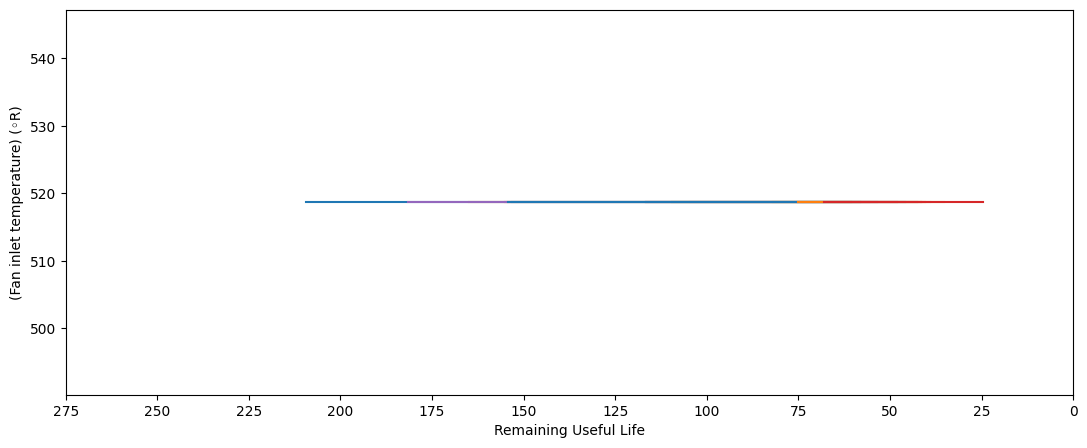

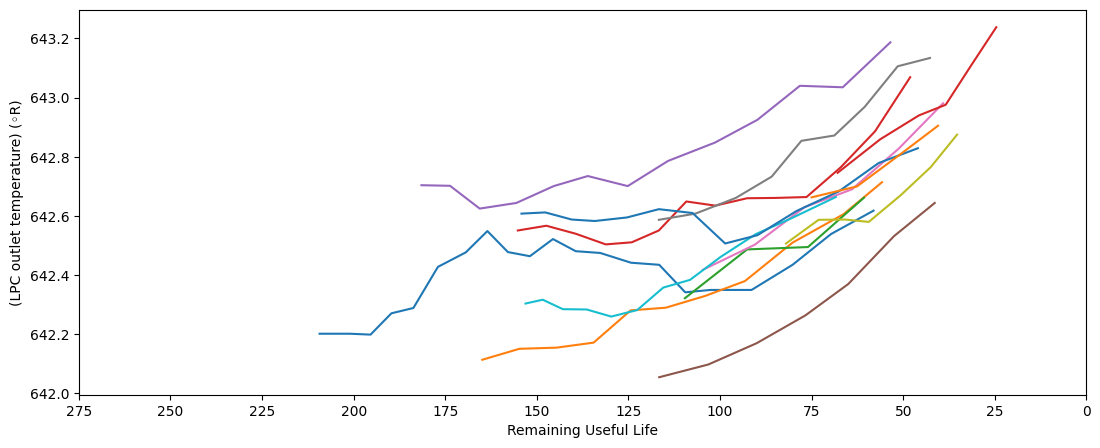

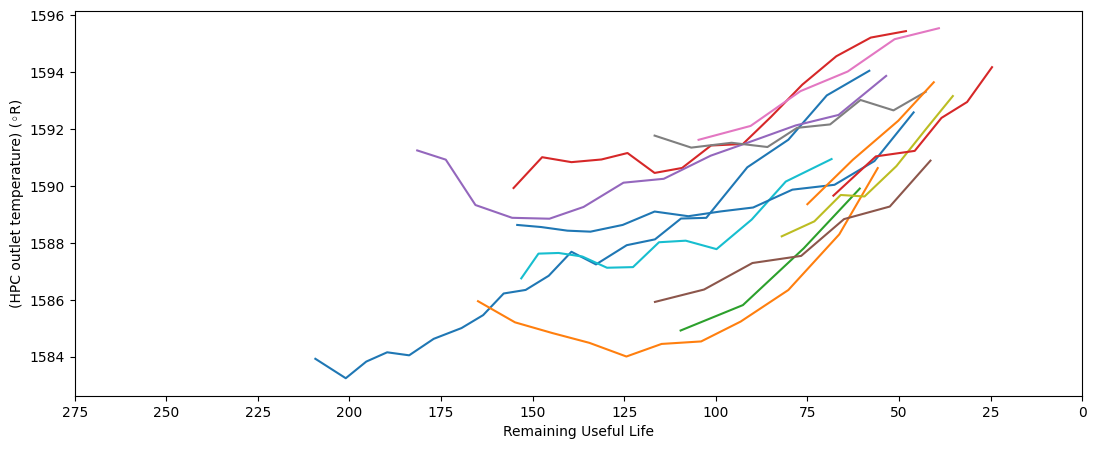

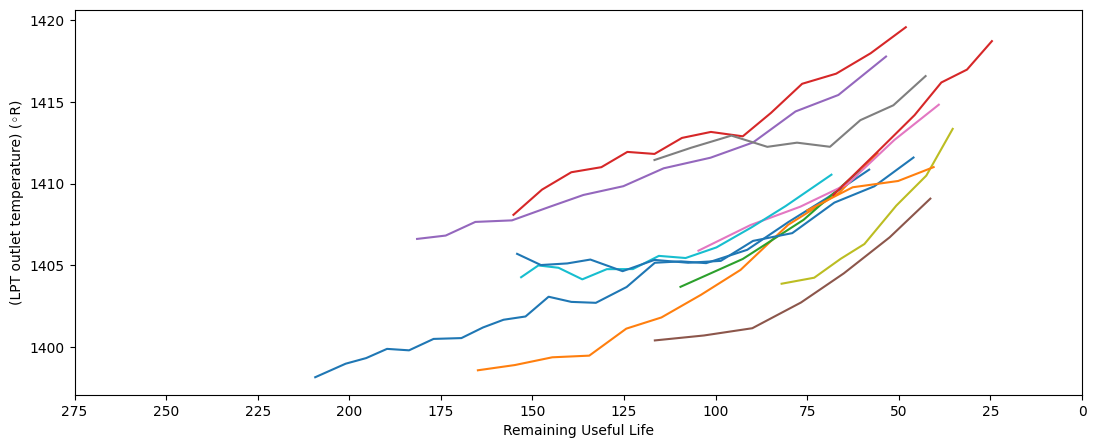

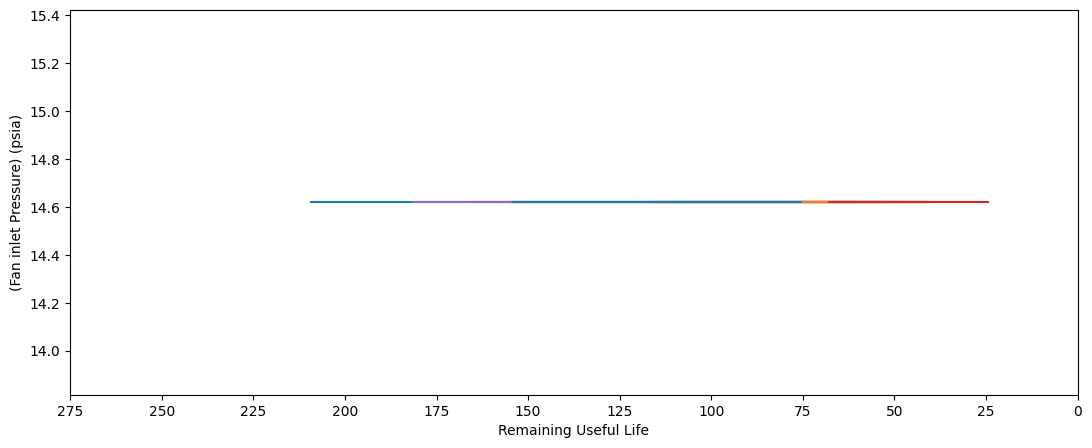

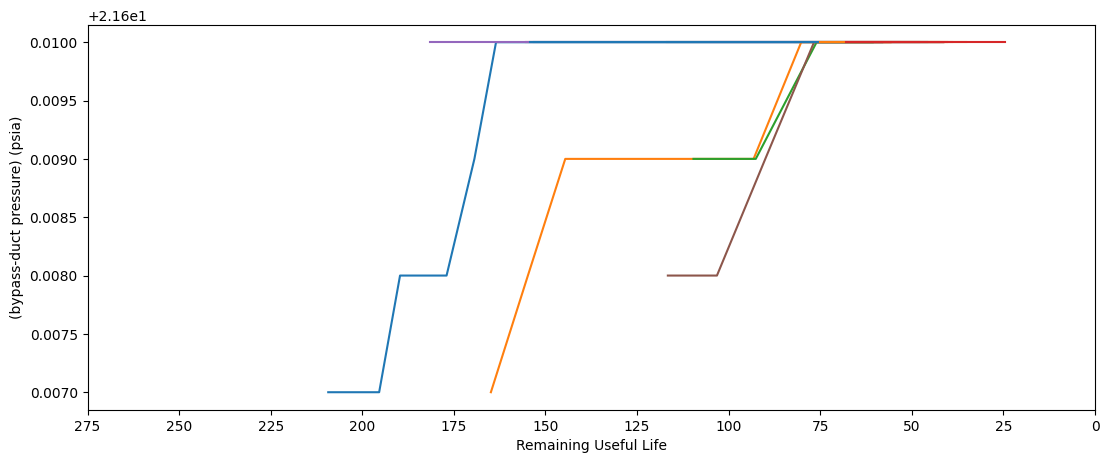

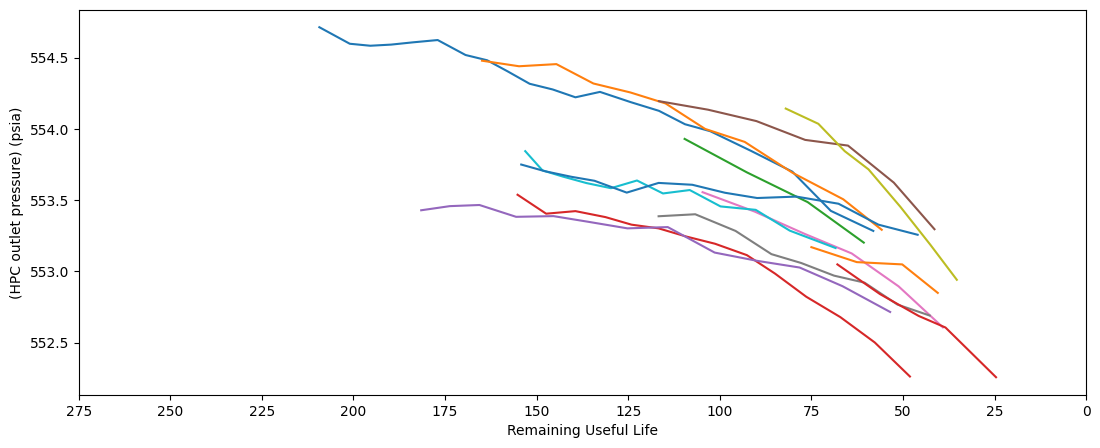

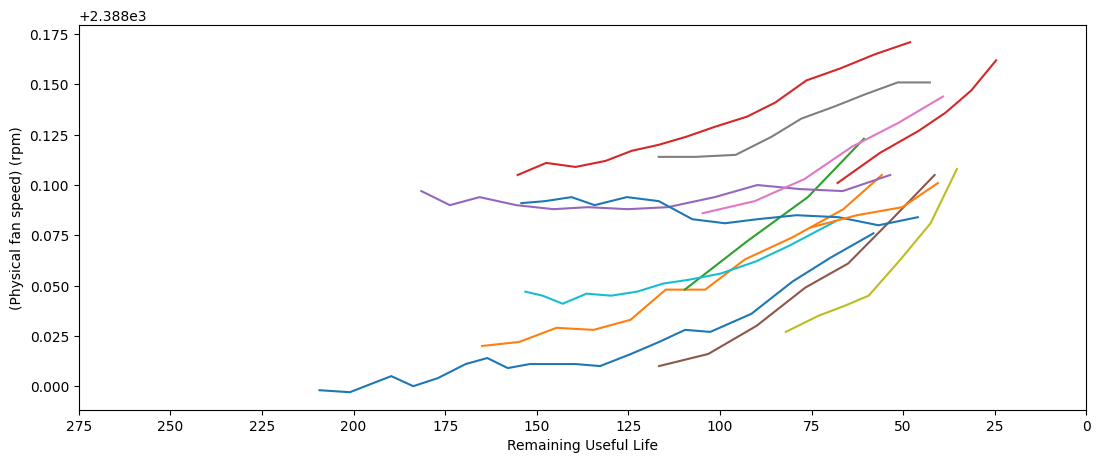

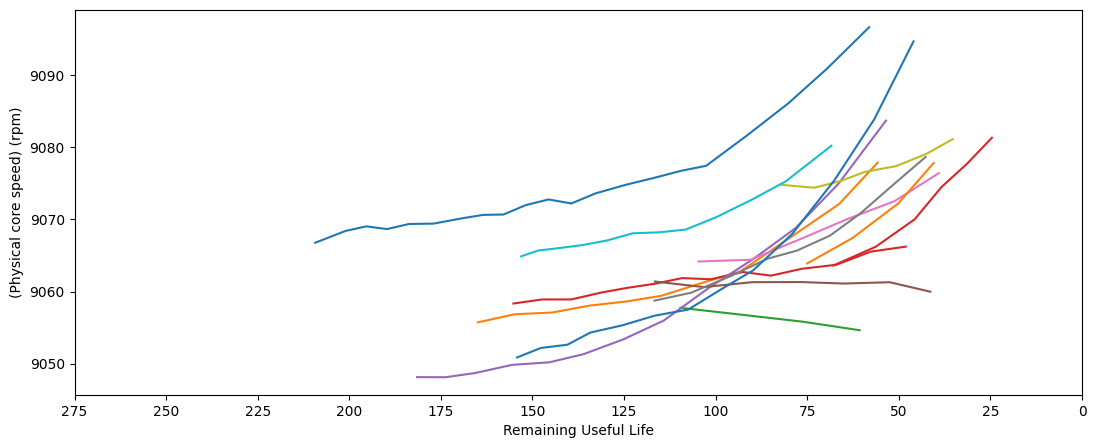

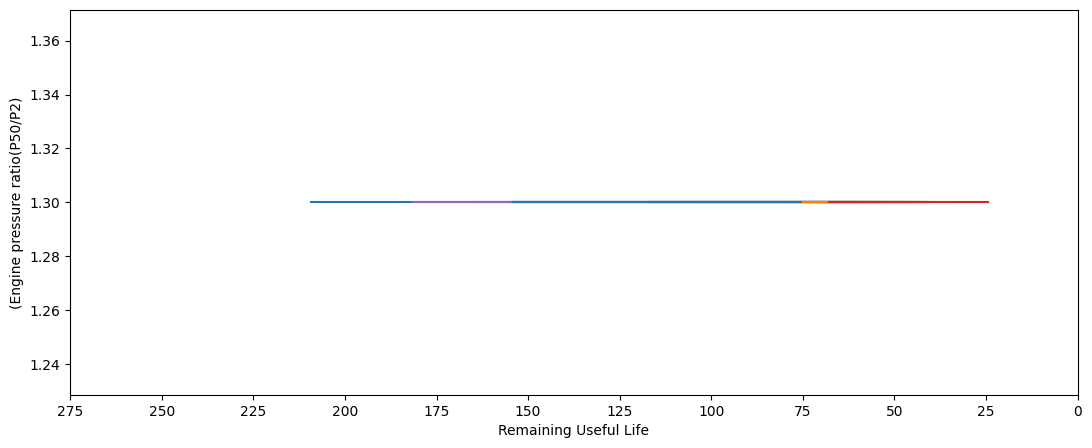

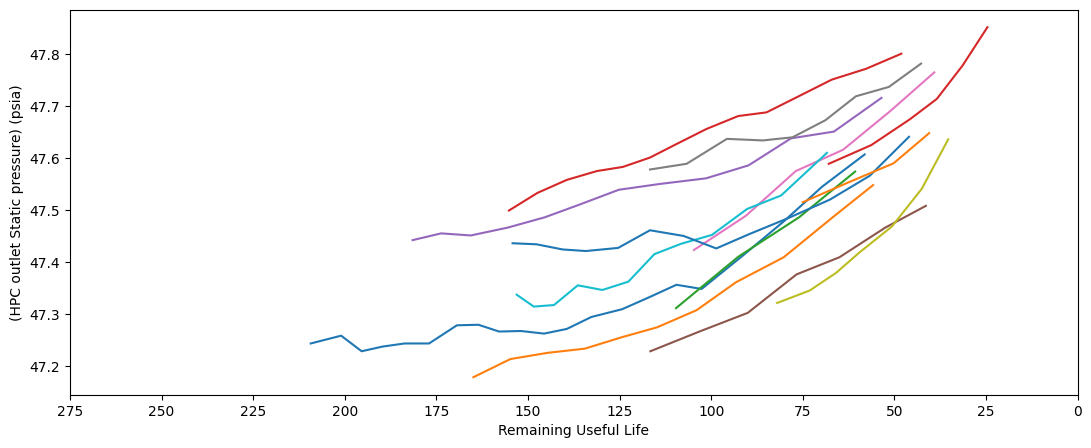

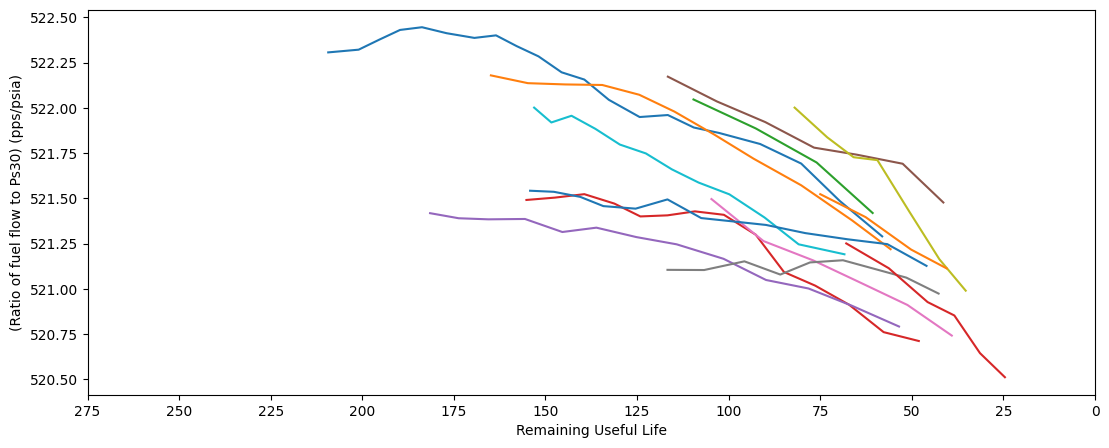

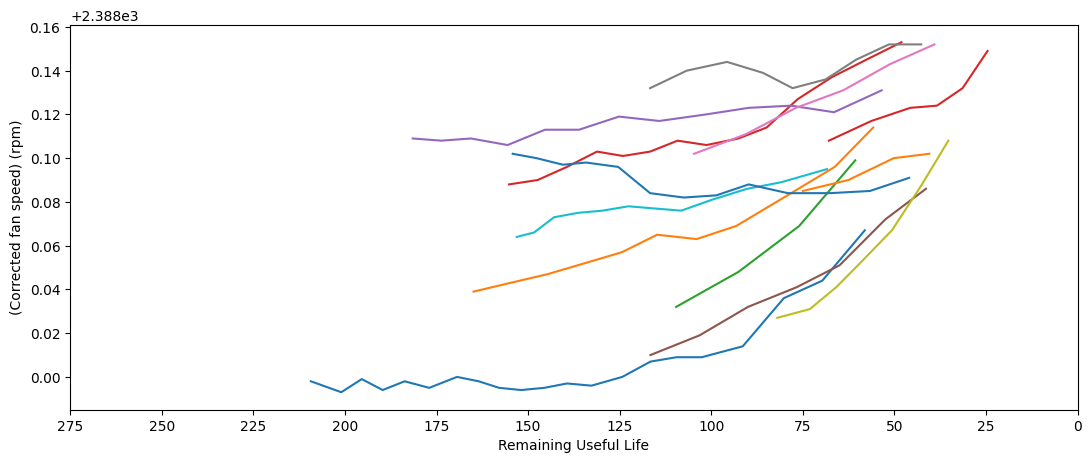

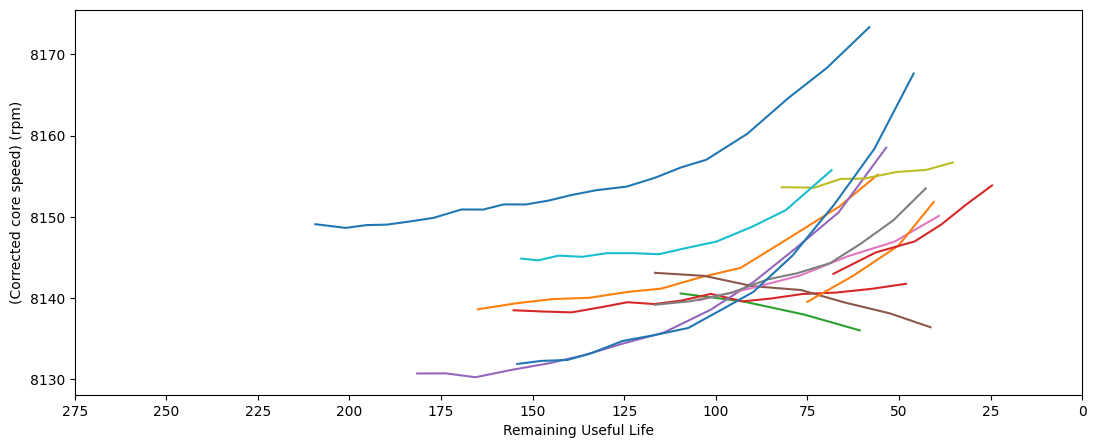

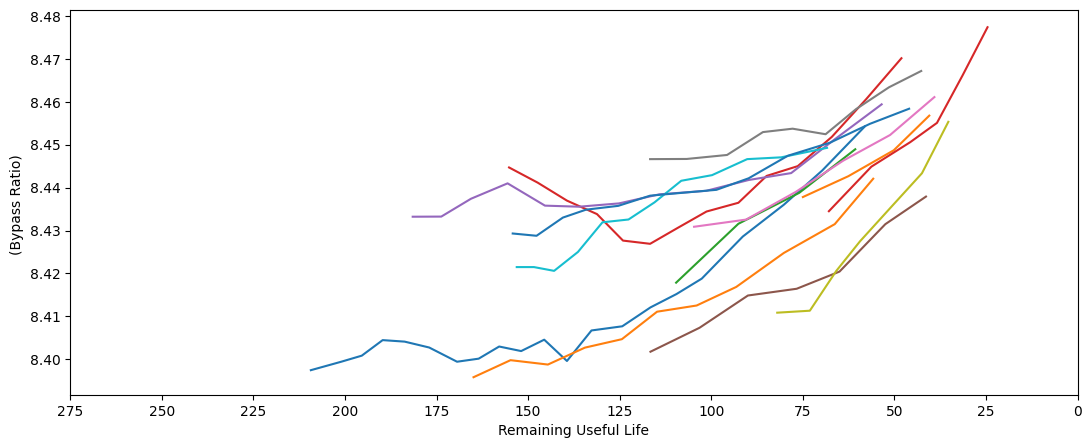

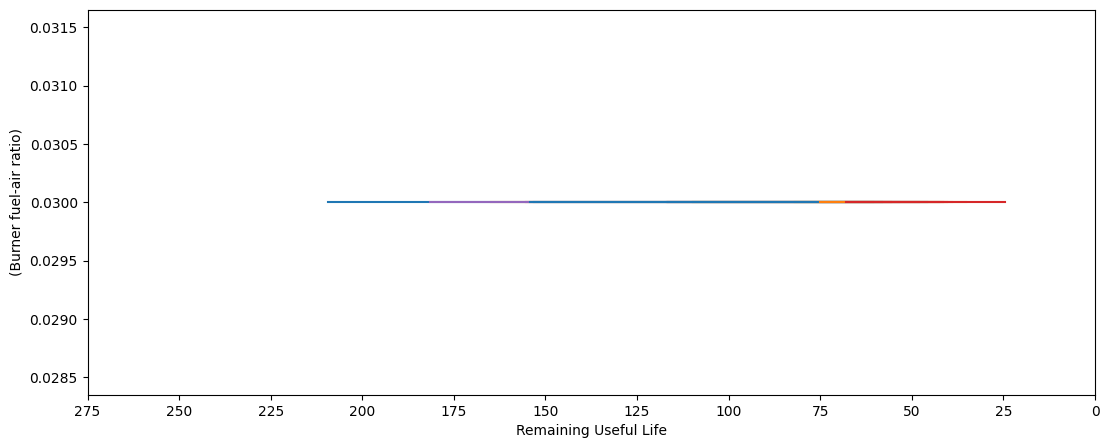

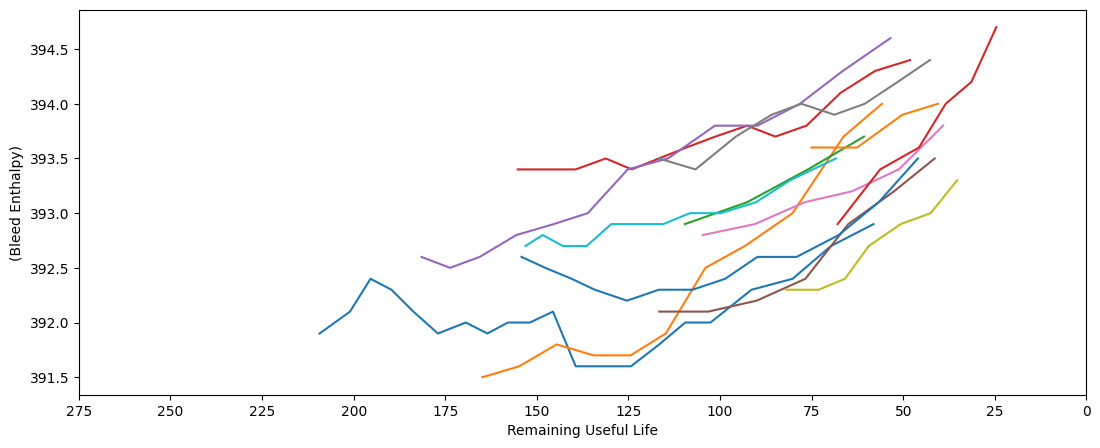

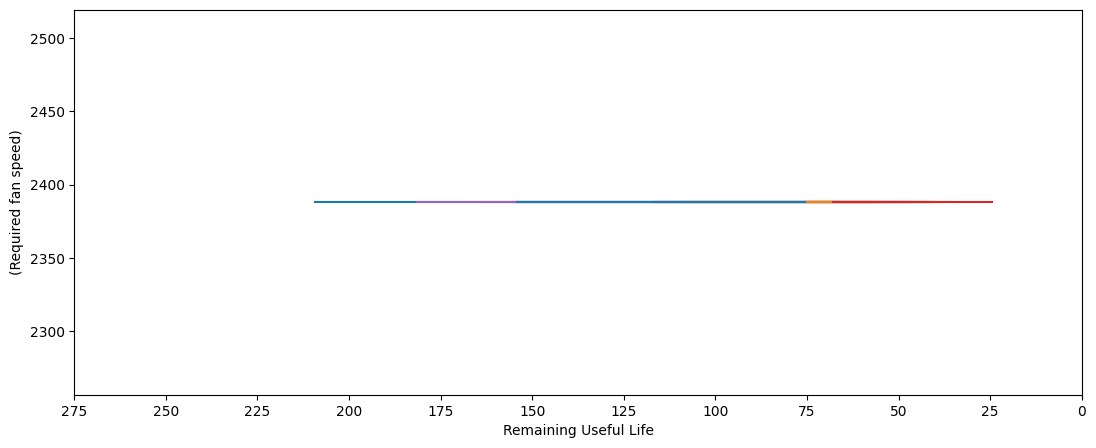

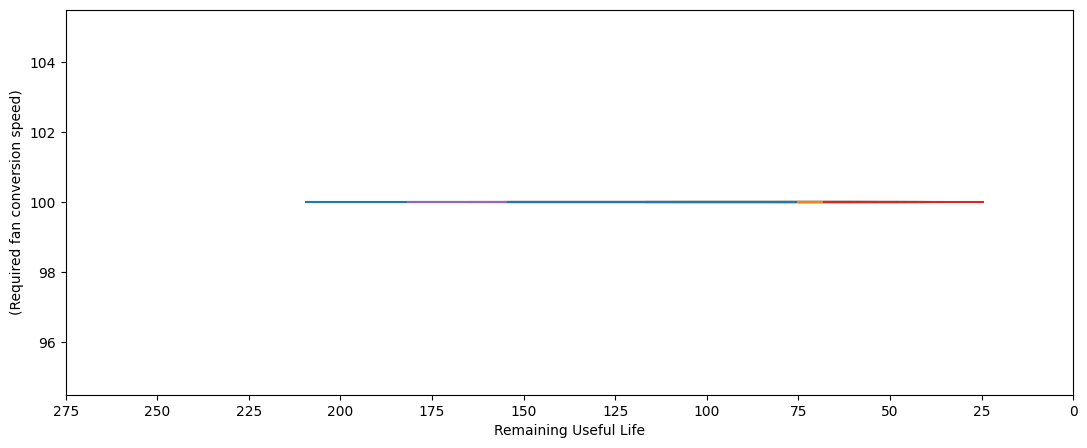

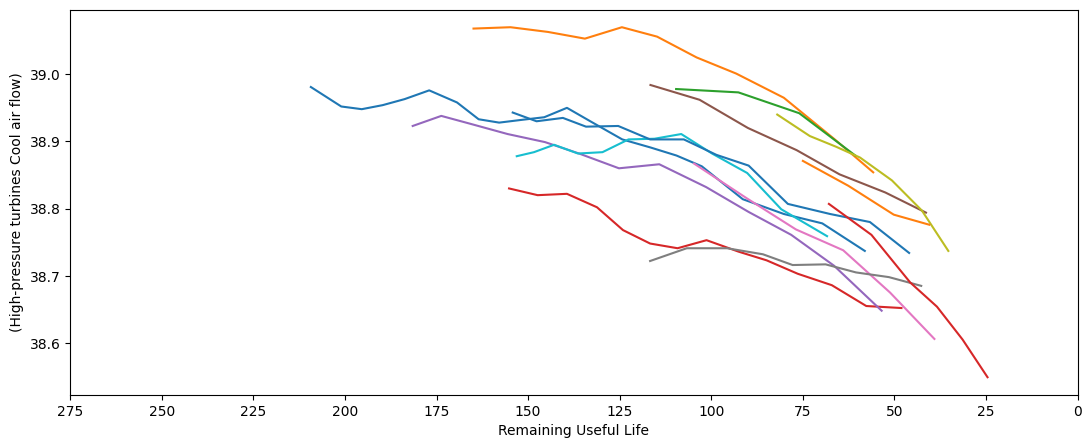

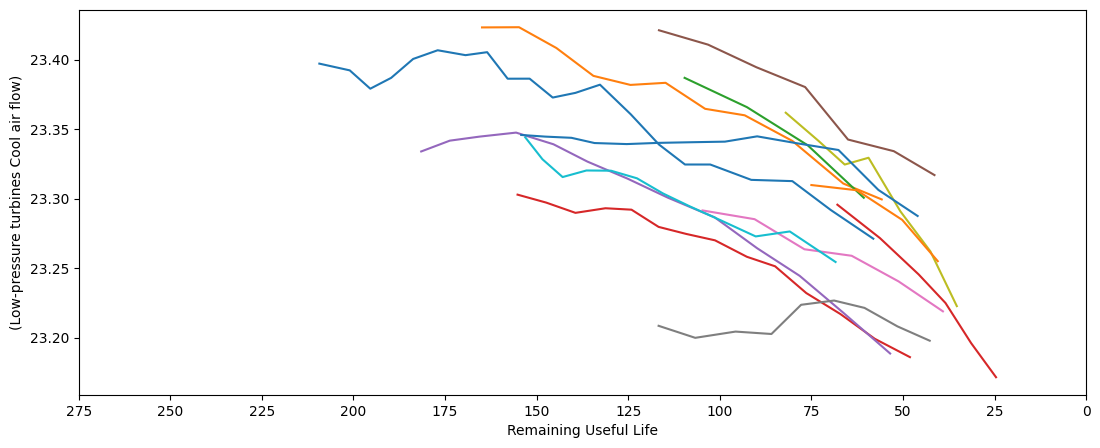

In [13]:
for i in range(1,22):
    try:
        plot_signal(train, Sensor_dictionary,'s_'+str(i))
    except:
        pass

MinMax scaler function : Transform features by scaling each feature to a given range.

This estimater scales and translates each feature individually such that it is in the given range on the training set

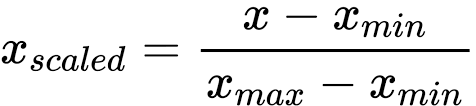

Dropping unnecessary features (labels and settings)

In [14]:
from sklearn.model_selection import train_test_split
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()

Scaling the data

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [16]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
0      518.67  641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06   
40     518.67  642.40  1591.31  1403.21  14.62  21.61  553.72  2388.06   
43     518.67  641.93  1586.94  1401.20  14.62  21.61  554.15  2388.04   
76     518.67  642.55  1586.30  1400.97  14.62  21.61  554.61  2388.06   
87     518.67  641.96  1581.29  1406.09  14.62  21.61  554.48  2388.07   
...       ...     ...      ...      ...    ...    ...     ...      ...   
13966  518.67  644.19  1604.62  1427.29  14.62  21.61  551.70  2388.26   
13972  518.67  642.68  1597.54  1423.81  14.62  21.61  551.05  2388.22   
13987  518.67  643.86  1601.80  1428.18  14.62  21.61  550.53  2388.25   
13988  518.67  643.74  1609.53  1428.26  14.62  21.61  551.60  2388.20   
13990  518.67  643.97  1597.75  1428.85  14.62  21.61  551.32  2388.31   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
0      9046.19   1.3  ...  521

In [17]:
print(X_train_s)

[[0.         0.14102564 0.43821161 ... 0.         0.8        0.73824632]
 [0.         0.32692308 0.48292141 ... 0.         0.86363636 0.77487742]
 [0.         0.17628205 0.36156623 ... 0.         0.8        0.81944044]
 ...
 [0.         0.79487179 0.77422938 ... 0.         0.34545455 0.31179694]
 [0.         0.75641026 0.98889197 ... 0.         0.31818182 0.21315258]
 [0.         0.83012821 0.66176062 ... 0.         0.26363636 0.19483703]]


In [18]:
print(X_valid_s.shape)
print(y_valid.shape)
print(X_valid)
print(X_valid_s)

(650, 21)
(650, 1)
         s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
16    518.67  642.26  1583.56  1407.35  14.62  21.61  552.63  2388.11   
28    518.67  642.67  1591.28  1396.89  14.62  21.61  553.46  2388.10   
37    518.67  642.88  1582.03  1403.44  14.62  21.61  553.16  2388.10   
40    518.67  643.09  1582.02  1409.96  14.62  21.61  553.39  2388.13   
42    518.67  641.93  1591.89  1405.30  14.62  21.61  553.38  2388.12   
...      ...     ...      ...      ...    ...    ...     ...      ...   
6471  518.67  643.05  1593.56  1420.48  14.62  21.61  551.80  2388.19   
6478  518.67  642.98  1594.80  1422.69  14.62  21.61  551.86  2388.18   
6483  518.67  643.34  1594.60  1427.27  14.62  21.61  551.83  2388.20   
6497  518.67  643.54  1604.50  1433.58  14.62  21.61  550.86  2388.23   
6499  518.67  643.23  1605.26  1426.53  14.62  21.61  550.68  2388.25   

          s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
16    9042.10   1.3  ...

In [19]:
print(y_valid)

      RUL
16    175
28    163
37    154
40    151
42    149
...   ...
6471   28
6478   21
6483   16
6497    2
6499    0

[650 rows x 1 columns]


Plotting features new distribution

# Model Implementation

Linear regression

Defining evaluation functions

In [20]:
# R2 score & RMSE & MSE
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat) # R2 score (R-squared) : indep. var.이 depend. var.을 얼마나 잘 설명하는가 (회귀모델 평가지표)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))

In [21]:
# plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):

    indices = np.arange(len(y_test_hat))
    wth= 0.6                                # width
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values] # y : RUL
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

**Use all feature**

In [22]:
print(X_train)

          s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8  \
0      518.67  641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06   
40     518.67  642.40  1591.31  1403.21  14.62  21.61  553.72  2388.06   
43     518.67  641.93  1586.94  1401.20  14.62  21.61  554.15  2388.04   
76     518.67  642.55  1586.30  1400.97  14.62  21.61  554.61  2388.06   
87     518.67  641.96  1581.29  1406.09  14.62  21.61  554.48  2388.07   
...       ...     ...      ...      ...    ...    ...     ...      ...   
13966  518.67  644.19  1604.62  1427.29  14.62  21.61  551.70  2388.26   
13972  518.67  642.68  1597.54  1423.81  14.62  21.61  551.05  2388.22   
13987  518.67  643.86  1601.80  1428.18  14.62  21.61  550.53  2388.25   
13988  518.67  643.74  1609.53  1428.26  14.62  21.61  551.60  2388.20   
13990  518.67  643.97  1597.75  1428.85  14.62  21.61  551.32  2388.31   

           s_9  s_10  ...    s_12     s_13     s_14    s_15  s_16  s_17  s_18  \
0      9046.19   1.3  ...  521

In [23]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1


**Linear regression**

In [24]:
print(X_train_1_s)
print(X_train_1_s.shape)
print(X_valid_1_s)
print(X_valid_1_s.shape)
print(X_full_1_s)
print(X_full_1_s.shape)

[[0.         0.14102564 0.43821161 ... 0.         0.8        0.73824632]
 [0.         0.32692308 0.48292141 ... 0.         0.86363636 0.77487742]
 [0.         0.17628205 0.36156623 ... 0.         0.8        0.81944044]
 ...
 [0.         0.79487179 0.77422938 ... 0.         0.34545455 0.31179694]
 [0.         0.75641026 0.98889197 ... 0.         0.31818182 0.21315258]
 [0.         0.83012821 0.66176062 ... 0.         0.26363636 0.19483703]]
(1398, 21)
[[0.         0.30278884 0.34693311 ... 0.         0.38679245 0.61414952]
 [0.         0.46613546 0.561199   ... 0.         0.45283019 0.55410604]
 [0.         0.5498008  0.3044685  ... 0.         0.53773585 0.68523164]
 ...
 [0.         0.73306773 0.65334444 ... 0.         0.22641509 0.22946981]
 [0.         0.812749   0.92811546 ... 0.         0.04716981 0.37748787]
 [0.         0.68924303 0.94920899 ... 0.         0.03773585 0.21792942]]
(650, 21)
[[0.         0.3993808  0.26682757 ... 0.         0.63636364 0.61546675]
 [0.         0.405

In [25]:
print(y_train_clip)
print(y_train_clip.shape)

0        190
40       150
43       147
76       114
87       103
        ... 
13966     24
13972     18
13987      3
13988      2
13990      0
Name: RUL, Length: 1398, dtype: int64
(1398,)


# **Loss function Tuning**

**1. Original MSE**

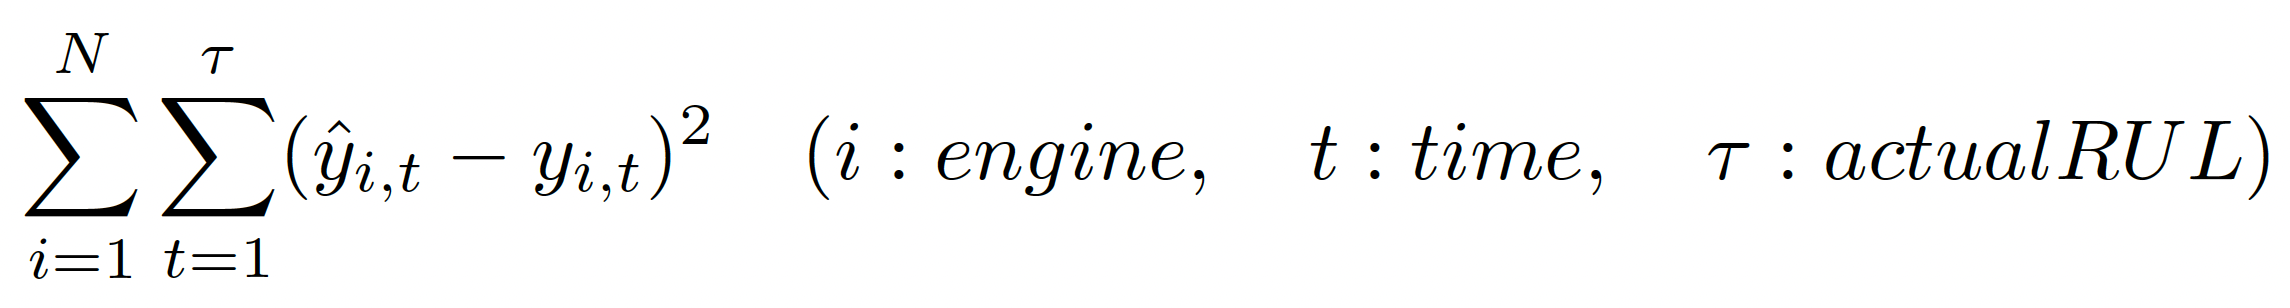

In [26]:

# 1. Original Linear Regression (모든 데이터 사용)
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')

print(lr1.coef_)

train set RMSE:38.90664762913199, R2:0.5966976540334432
valid set RMSE:53.26669905070031, R2:0.4988817376292962
full data set RMSE:47.18802427173152, R2:0.5412780975113607
[ 0.00000000e+00 -6.30299469e+00 -8.49894008e+00 -2.17325812e+01
  7.10542736e-15 -5.39944418e+00  3.60886617e+01 -1.67027397e+01
 -6.54830906e+01  3.55271368e-15 -6.83023676e+01  4.38825351e+01
  9.16928803e+00 -4.13898206e+01 -2.77291794e+01  0.00000000e+00
 -2.28437995e+01  1.14794370e-39 -1.83670992e-40  1.51142025e+01
  2.07236265e+01]


**2. Crucial moments Loss function**

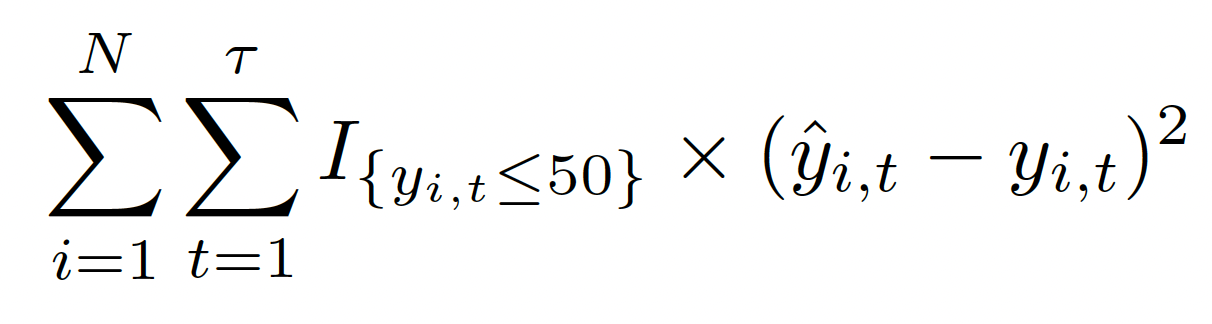

In [27]:
# 2. Crucial moments loss function - Linear Regression

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')

print(lr2.coef_)

train set RMSE:78.46999474829148, R2:-0.6405534029950155
valid set RMSE:94.40523057813103, R2:-0.5740581638451099
full data set RMSE:86.98318757521682, R2:-0.5586784320583391
[ 0.00000000e+00 -7.02214722e+00  2.53538606e+00 -9.00602917e+00
  1.06581410e-14  7.67058321e+00  3.97941221e+00  3.25183216e+00
 -3.21145100e+01 -7.10542736e-15 -2.41657211e+01  1.56987431e+01
 -2.14591578e+01  7.57090867e+00 -5.32504927e-01  0.00000000e+00
 -4.62026221e+00  9.18354962e-41 -9.18354962e-41  9.79548728e-02
  3.05011504e+00]


**3. TD Style Loss function (ridge regression)**

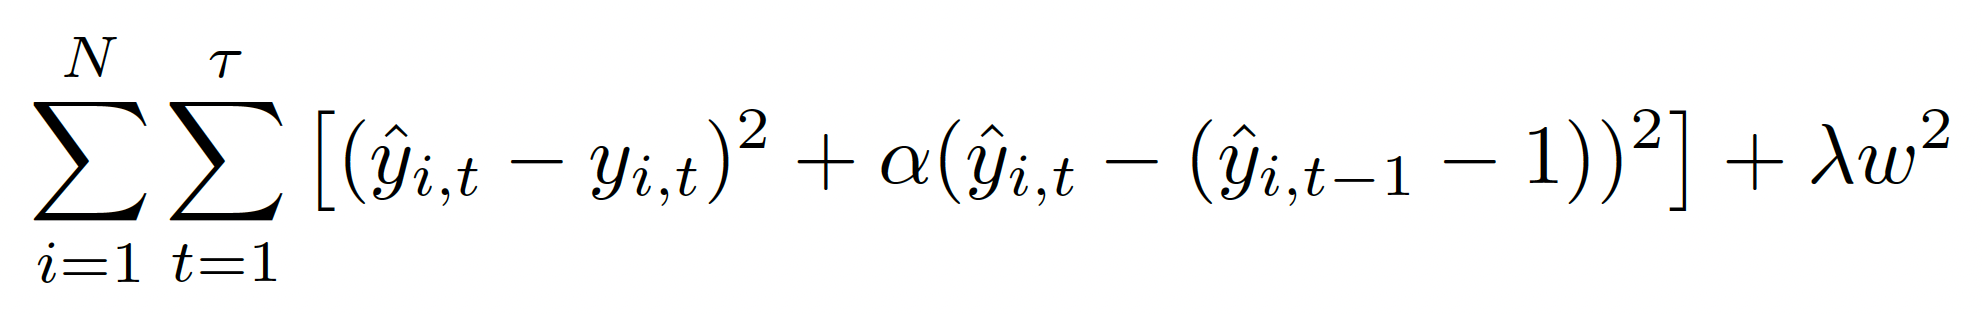

In [28]:
# Multi var linear regression

class Linear_Regression_TD() :
  def __init__( self, alpha=0, lambda_ridge=0 ) :
    self.alpha = alpha
    self.lambda_ridge = lambda_ridge  # Ridge regression

  def fit(self, X, Y, alpha, lambd) :
    self.l, self.p = X.shape
    self.alpha = alpha
    self.lambda_ridge = lambd
    # weight initializer
    self.p = (self.p + 1)         # add constant term.

    self.add_X = np.ones(self.l)
    self.X = np.c_[self.add_X, X]

    self.array_Y = np.array(Y[0:].to_numpy())
    self.array_Y.reshape( self.l, 1 )
    self.Y = self.array_Y
    self.W = np.zeros( self.p ) # W : 0 (b is included)

    self.identity = np.identity( n = self.p ) # Ridge regression
    self.lambda_identity = self.lambda_ridge * self.identity   # lambda * I

    # 각각의 행렬 연산
    X_T_X = (self.X.T) @ (self.X)          # X^(T)X
    X_diff_T_X_diff_sum = np.zeros( [self.p, self.p] )

    for i in range(1, self.l):
      X_diff_T_X_diff = (( self.X[i, :] - self.X[i - 1, :] ).reshape(self.p, 1)) @ (( self.X[i, :] - self.X[i - 1, :] ).reshape(1, self.p))
      X_diff_T_X_diff_sum += X_diff_T_X_diff


    X_T_Y = (self.X.T) @ (self.Y)
    X_T_Y = X_T_Y.reshape( self.p, 1 )
    X_diff_T_sum = np.zeros( [self.p, 1] )

    for i in range(1, self.l):
      X_diff_T = (( self.X[i, :] - self.X[i - 1, :] ).reshape( self.p, 1 ))
      X_diff_T_sum += X_diff_T

    self.W = np.linalg.inv(X_T_X + (self.alpha * X_diff_T_X_diff_sum) + self.lambda_identity) @ (X_T_Y - self.alpha * X_diff_T_sum)

    print(self.W)
    print(self.W.shape)

# X를 입력 받으면 첫 열에 1의 값을 갖는 열을 추가해서 계산해야함. (입력으로 들어오는 X는 (n, 21)이니 (n, 22)로 바꿔줘야 함)
  def predict( self, X) :
    l_X, p_X = X.shape
    p_X = p_X + 1
    add_col = np.ones(l_X)

    X = np.c_[add_col, X]

    return X.dot( self.W )

In [29]:
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


[[ 61.87861306]
 [  0.        ]
 [ -4.28972218]
 [ -5.63987083]
 [-15.39851268]
 [  0.        ]
 [  2.75531814]
 [ 37.91173503]
 [ -9.284134  ]
 [-31.19981332]
 [  0.        ]
 [-26.91348095]
 [ 42.95468037]
 [  4.30927426]
 [-27.12014784]
 [-16.01309138]
 [  0.        ]
 [-12.3797371 ]
 [  0.        ]
 [  0.        ]
 [ 28.79411635]
 [ 28.39689365]]
(22, 1)
train set RMSE:40.93599991826695, R2:0.5535283049621653
valid set RMSE:55.19150701764415, R2:0.46201128357436894
full data set RMSE:49.976054460290584, R2:0.48547104343736747


**4. TD Style Loss function + Crucial moments (ridge regression)**

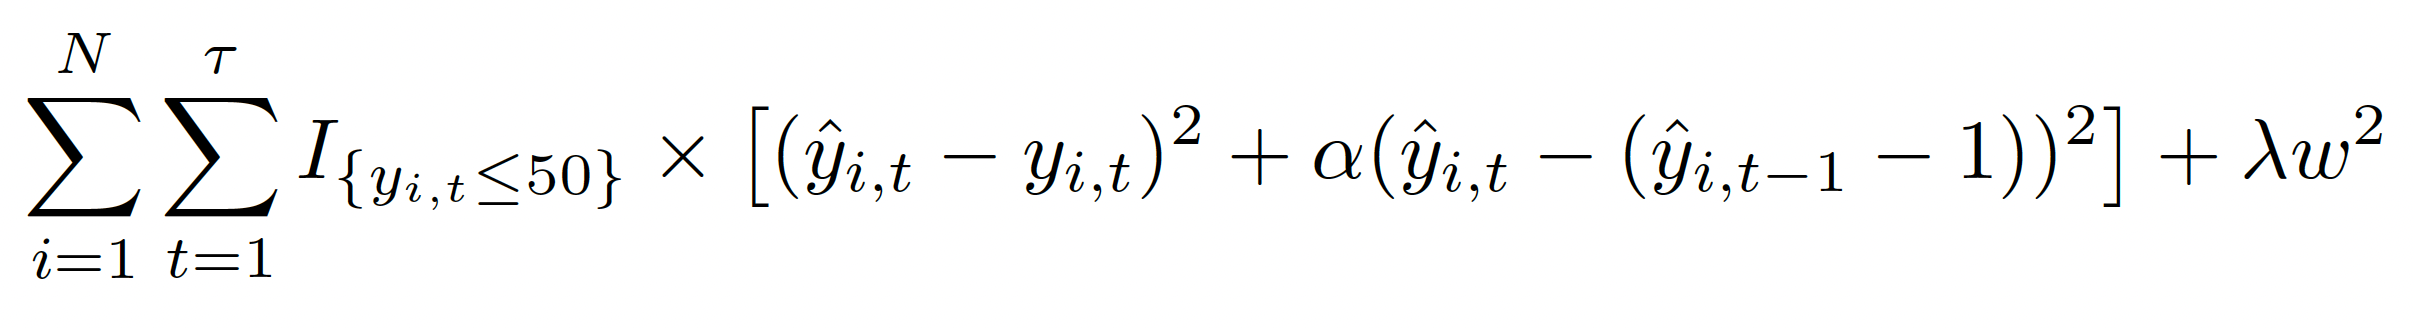

In [30]:
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')

[[10.65455949]
 [ 0.        ]
 [-1.973907  ]
 [-0.62900266]
 [-3.81669151]
 [ 0.        ]
 [ 7.39176634]
 [ 8.77334483]
 [-0.39761232]
 [-4.64889796]
 [ 0.        ]
 [-4.09956373]
 [ 9.88769885]
 [-3.22415609]
 [-3.82017962]
 [-0.68436561]
 [ 0.        ]
 [-1.36188404]
 [ 0.        ]
 [ 0.        ]
 [ 7.2131757 ]
 [ 8.6600005 ]]
(22, 1)
train set RMSE:86.82807255735001, R2:-1.0086461927848034
valid set RMSE:101.01853691498208, R2:-0.8023154678423299
full data set RMSE:95.97239682214132, R2:-0.8974859577883523


5. Directed MSE

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

In [32]:
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# Directed Mean Squared Error를 고려한 Loss function
def directed_mse_loss(y_true, y_pred):
    penalty = tf.where(y_pred > y_true, 13.0, 10.0)
    squared_error = tf.square(y_pred - y_true)
    return tf.reduce_mean(penalty * squared_error, axis=-1)

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

#predictions = lr5.predict(X_train_1_s).flatten()

In [33]:
y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data

65/65 [==============================] - 0s 2ms/step


6. Directed Crucial moments MSE (20)

In [34]:
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data

65/65 [==============================] - 0s 1ms/step


In [35]:
print(y_lr_train_6)
print(y_lr_full_6)

[[32.736935]
 [33.311016]
 [34.43503 ]
 ...
 [ 9.959656]
 [12.18581 ]
 [ 8.252514]]
[[31.569881 ]
 [29.221447 ]
 [32.92918  ]
 ...
 [15.8868685]
 [15.734189 ]
 [ 7.655155 ]]


Merge!

In [36]:
y_lr_valid_1

array([ 96.00382663, 102.54329311, 112.55457608, 103.02573074,
        98.9375223 , 121.98662972, 105.3750564 , 120.47228683,
        91.68427163,  94.83549209,  99.57442903, 112.47944201,
        79.06884844,  75.27916006,  90.60636405,  87.29926036,
        66.10722836,  65.19590086,  52.27436679,  30.59963221,
        37.39168539,  12.86144255,  24.29939708,  -1.70411524,
       -15.03158935, 130.07752717, 123.82485773, 137.66714151,
       121.91967866, 125.32489407, 136.21049051, 113.17248744,
       107.88971135, 106.39584211, 110.88725819,  97.51709642,
        91.37586672,  79.5491025 ,  67.35058644,  81.08425243,
        51.68769258,  12.82148795, -16.17541191,  89.76016751,
       113.1553542 ,  87.82409843, 105.42508835,  97.53356026,
       112.94408703,  73.94452828,  88.65529656,  86.04426127,
        65.42690892,  78.14772982,  65.35718005,  66.14578694,
        56.37823506,  30.04714569,  34.49646755,  28.68380659,
       135.87153254, 123.40400404, 111.01942168, 110.95

concat을 위해 index 제거. 제거하지 않으면 NaN 값들이 데이터프레임에 들어감.

In [37]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

In [38]:
# loss function 별 dataframe들을 list로 저장
y_lr_valid_dfs = [pd.DataFrame(y_lr_valid_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_valid_6, columns=['predicted RUL'])]
merged_valid_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_valid_df in enumerate(y_lr_valid_dfs, start=1):
    merged_valid = pd.concat([X_valid_index_names, y_lr_valid_df, y_valid], axis=1)
    merged_valid_dfs.append(merged_valid)
    print(f"Merged Valid DataFrame {i}:\n", merged_valid)

Merged Valid DataFrame 1:
      unit_number  time_cycles  predicted RUL  RUL
0             71           17      96.003827  175
1             71           29     102.543293  163
2             71           38     112.554576  154
3             71           41     103.025731  151
4             71           43      98.937522  149
..           ...          ...            ...  ...
645          100          171      19.501101   28
646          100          178      12.348061   21
647          100          183       6.432486   16
648          100          197     -18.790937    2
649          100          199     -44.710528    0

[650 rows x 4 columns]
Merged Valid DataFrame 2:
      unit_number  time_cycles  predicted RUL  RUL
0             71           17      40.143936  175
1             71           29      40.016483  163
2             71           38      41.615144  154
3             71           41      38.293269  151
4             71           43      38.387107  149
..           ...      

In [39]:
# loss function 별 dataframe들을 list로 저장
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8     152.889939  182
1               1           17     135.476924  173
2               1           28     147.549395  162
3               1           32     153.865655  158
4               1           40     144.789804  150
...           ...          ...            ...  ...
2058          100          167      48.389688   33
2059          100          168      38.487943   32
2060          100          170      24.010075   30
2061          100          173      34.616300   27
2062          100          200     -16.268358    0

[2063 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1            8      54.859481  182
1               1           17      52.743681  173
2               1           28      51.534211  162
3               1           32      52.531144  158
4               1           40      51.381191  150
...  

# Visualization

**(1) 각 엔진의 online predict value (test data 71~100)**

(X-axis : Time cycles, Y-axis : predicted RUL)

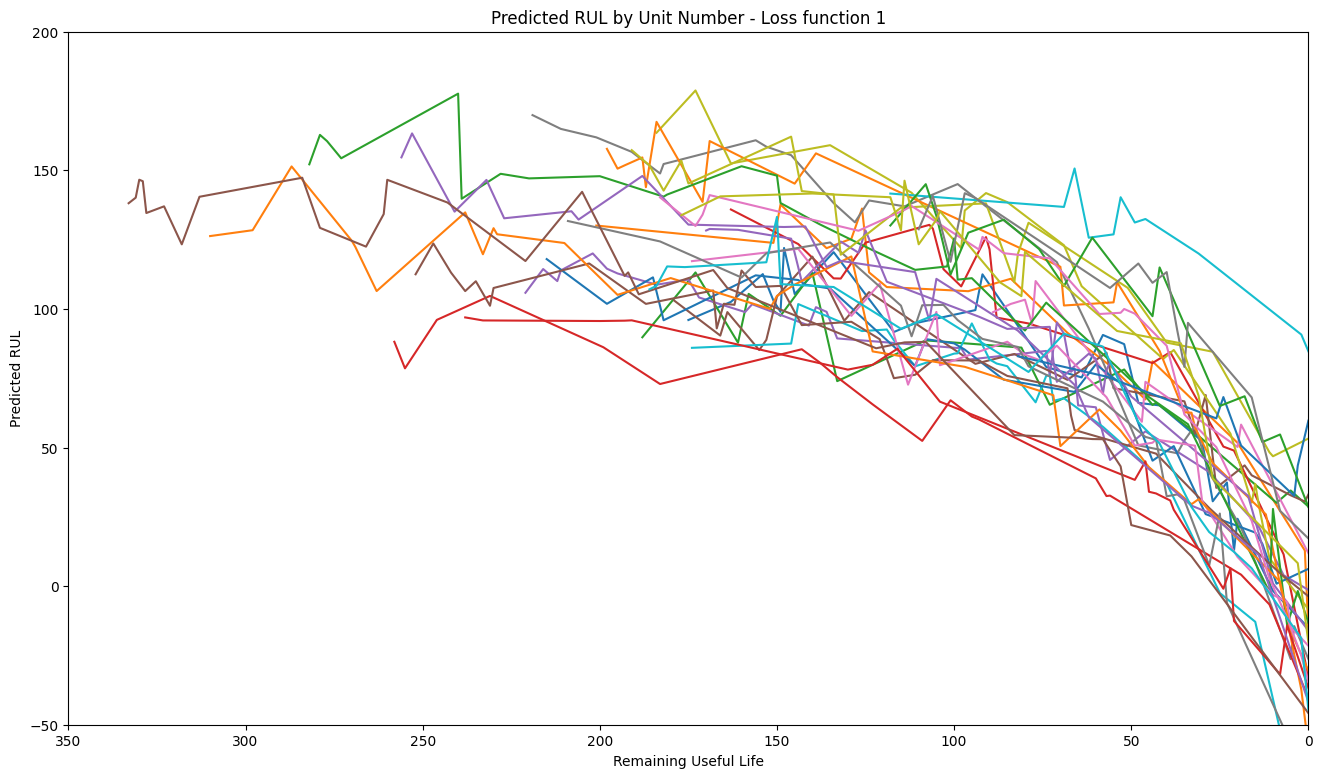

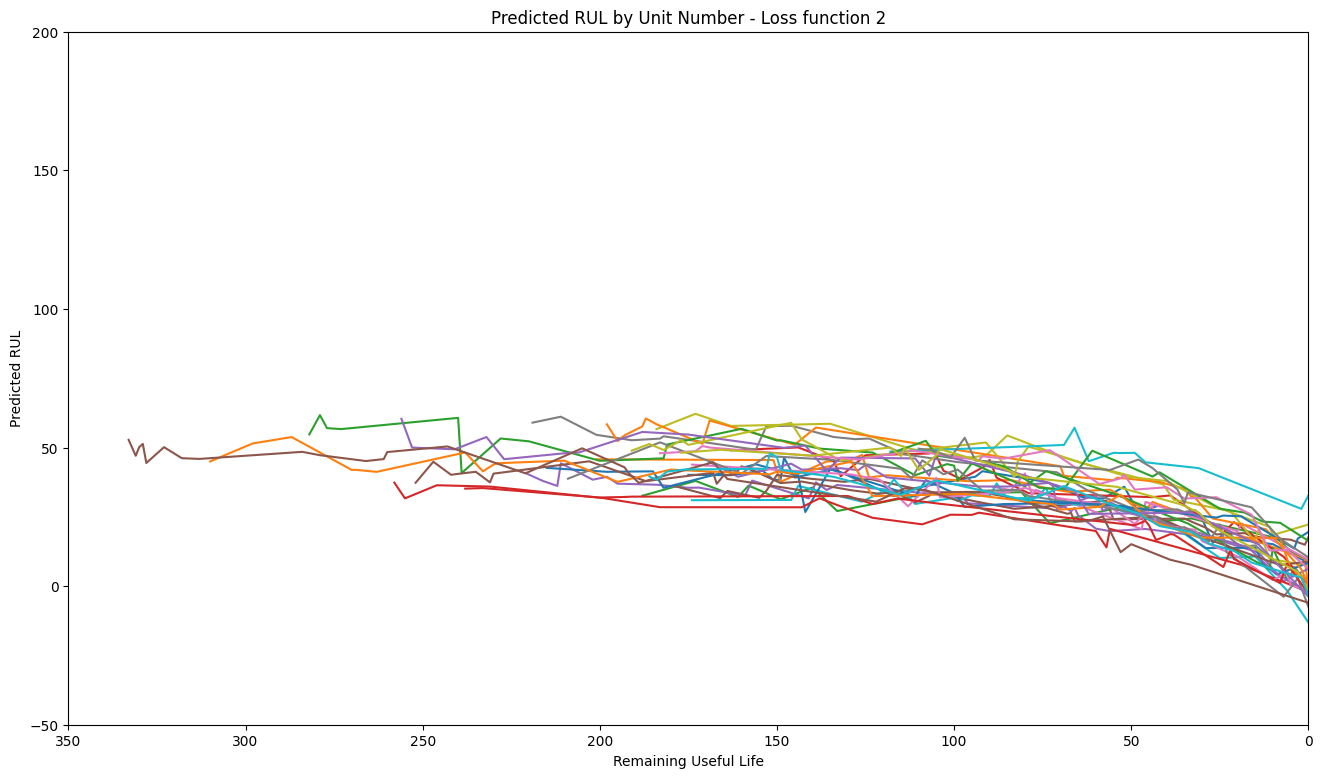

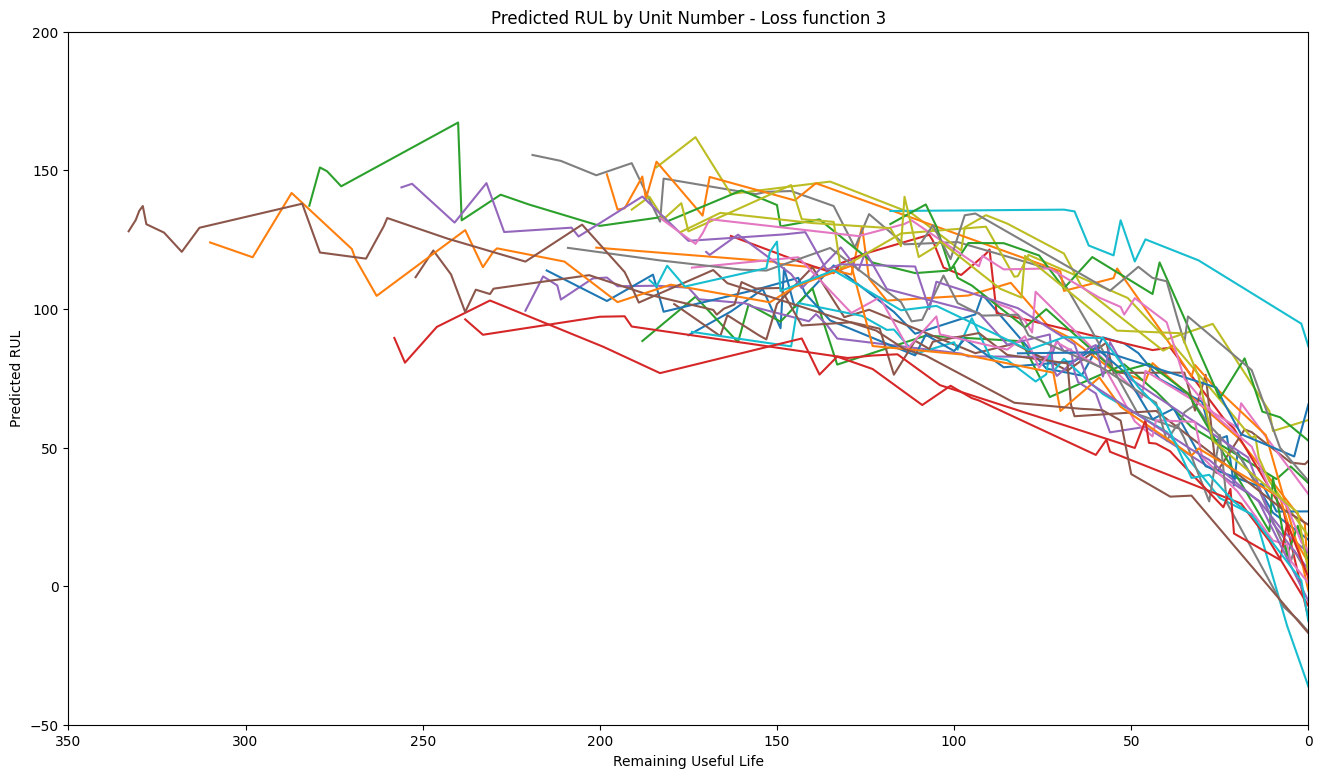

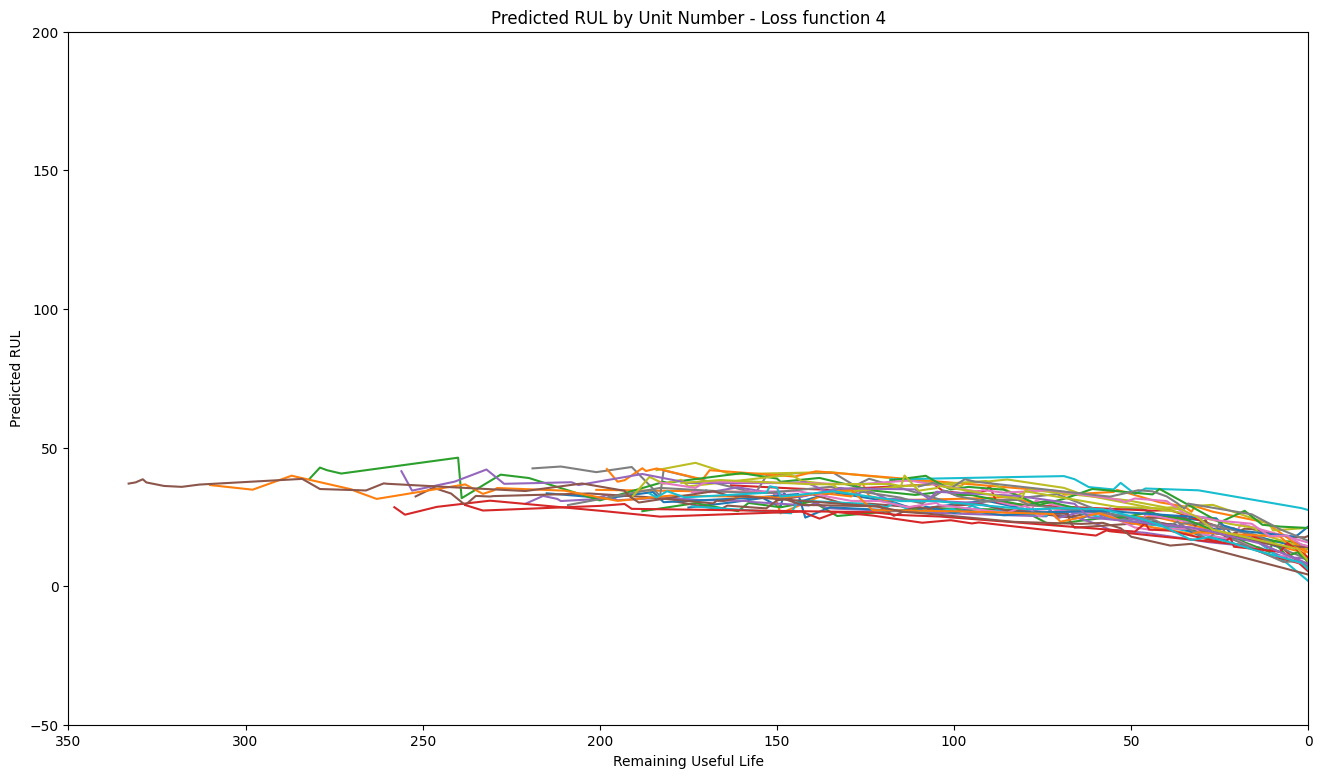

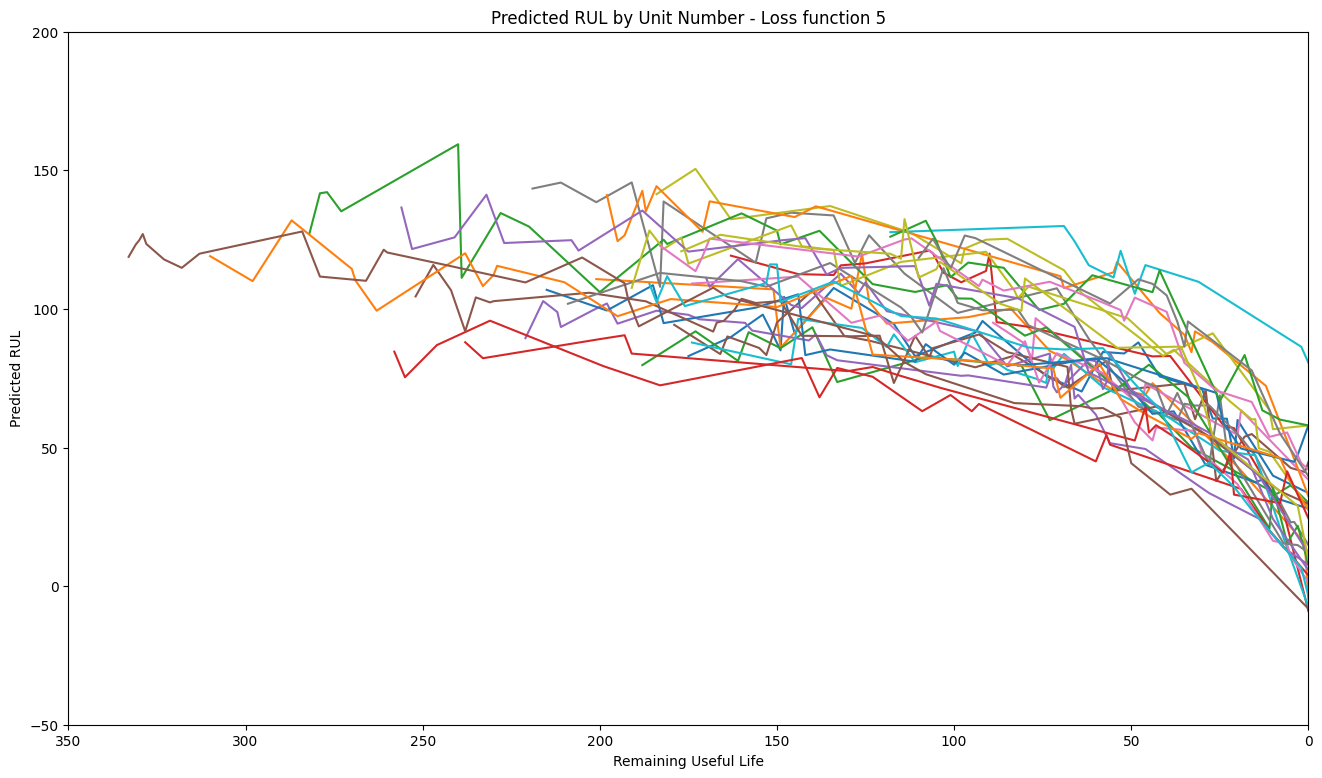

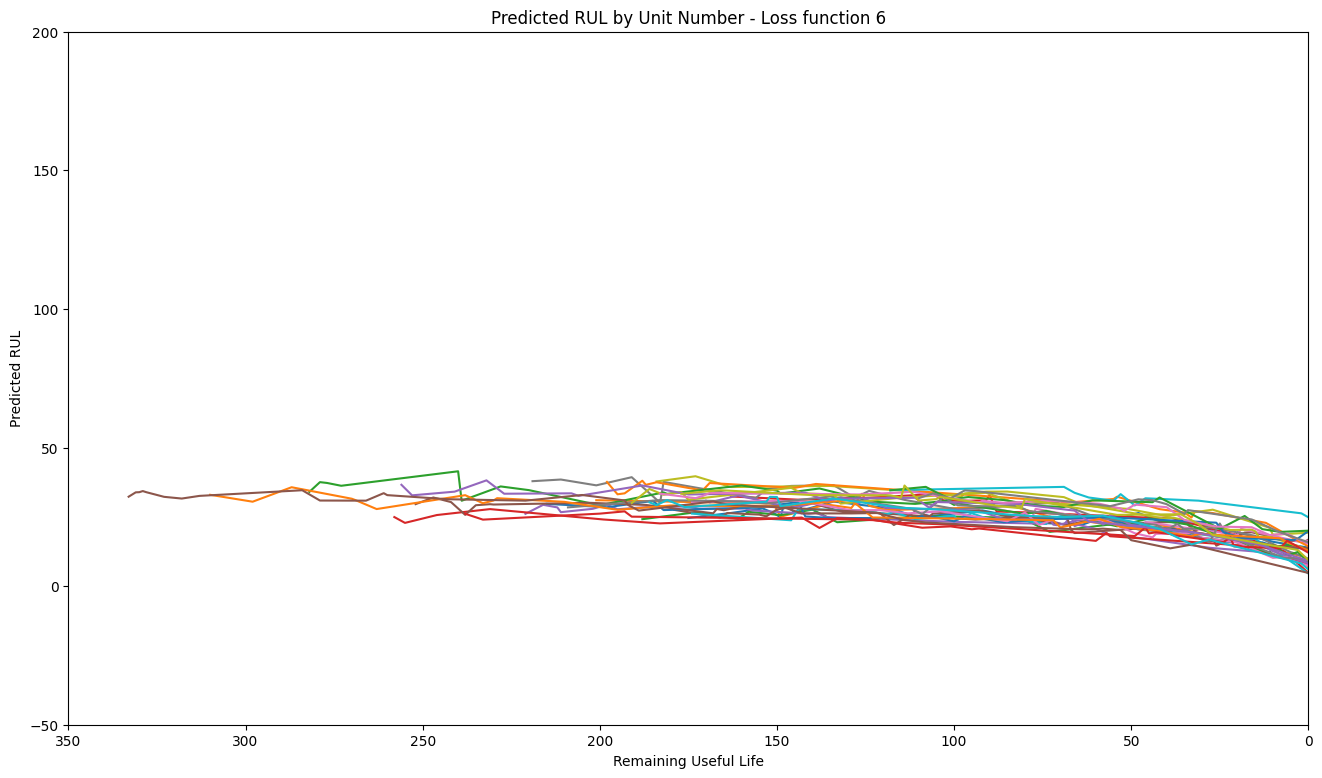

In [40]:
# merged_valid_dfs 리스트에 있는 데이터프레임들에 대해 반복 수행
for i, merged_valid_df in enumerate(merged_valid_dfs, start=1):
    # 데이터프레임에서 unit_number을 기준으로 그룹화
    grouped = merged_valid_df.groupby('unit_number')

    # 그래프를 그릴 subplot을 설정
    fig, ax = plt.subplots(figsize=(16, 9))

    # unit_number 별로 그래프 그리기
    for unit, group in grouped:
        ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

    ax.set_xlabel('Remaining Useful Life')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'Predicted RUL by Unit Number - Loss function {i}')
    #ax.legend(loc='upper right')  # 범례 추가

    # 그래프 출력 설정
    plt.xlim(350, 0)  # reverse the x-axis so RUL counts down to zero
    plt.ylim(-50, 200)
    plt.show()

**Threshold, Actual Operation Time**

**Add "Cumulative Operation Time", "Total Cost" Columns**


Cost : Failure (10,000), replace (1000)

**Apply full data set**

In [41]:
# define list of threshold_value
threshold_start = -40        # -40
threshold_end = 90           # 90
threshold_values = list(range(threshold_start, threshold_end + 1))

# Define cost (Tentative Value)
REPLACE_COST = 1000       # replace cost를 크게 늘려도, 반등하는 최저점을 찾을 수 없음 <- Total cost로 해서 상수가 나왔었음. 시간당 cost로 환산하면 커브 그려짐.
FAILURE_COST = 10000

In [42]:
# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()
            """
            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break
            """

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

**(2) Threshold를 x축으로 두고 분석**

(x-axis : Threshold, y-axis : Number of replace failures)


(x-axis : Threshold, y-axis : Total Cost)

**apply full data**

In [43]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          88   47.429149              188.07
1          -39                          87   46.950603              188.07
2          -38                          86   46.472058              188.07
3          -37                          86   46.472058              188.07
4          -36                          86   46.472058              188.07
..         ...                         ...         ...                 ...
126         86                           0    7.189589              139.09
127         87                           0    7.363228              135.81
128         88                           0    7.553441              132.39
129         89                           0    7.614986              131.32
130         90                           0    7.711884              129.67

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [44]:
full_nan_counts_and_cost_df_lists = []
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

**여기부터 average usage time 적용!**

**Scatter plot - Threshold에 따른 replace 실패 횟수와, 엔진 평균 사용시간 - Full data**

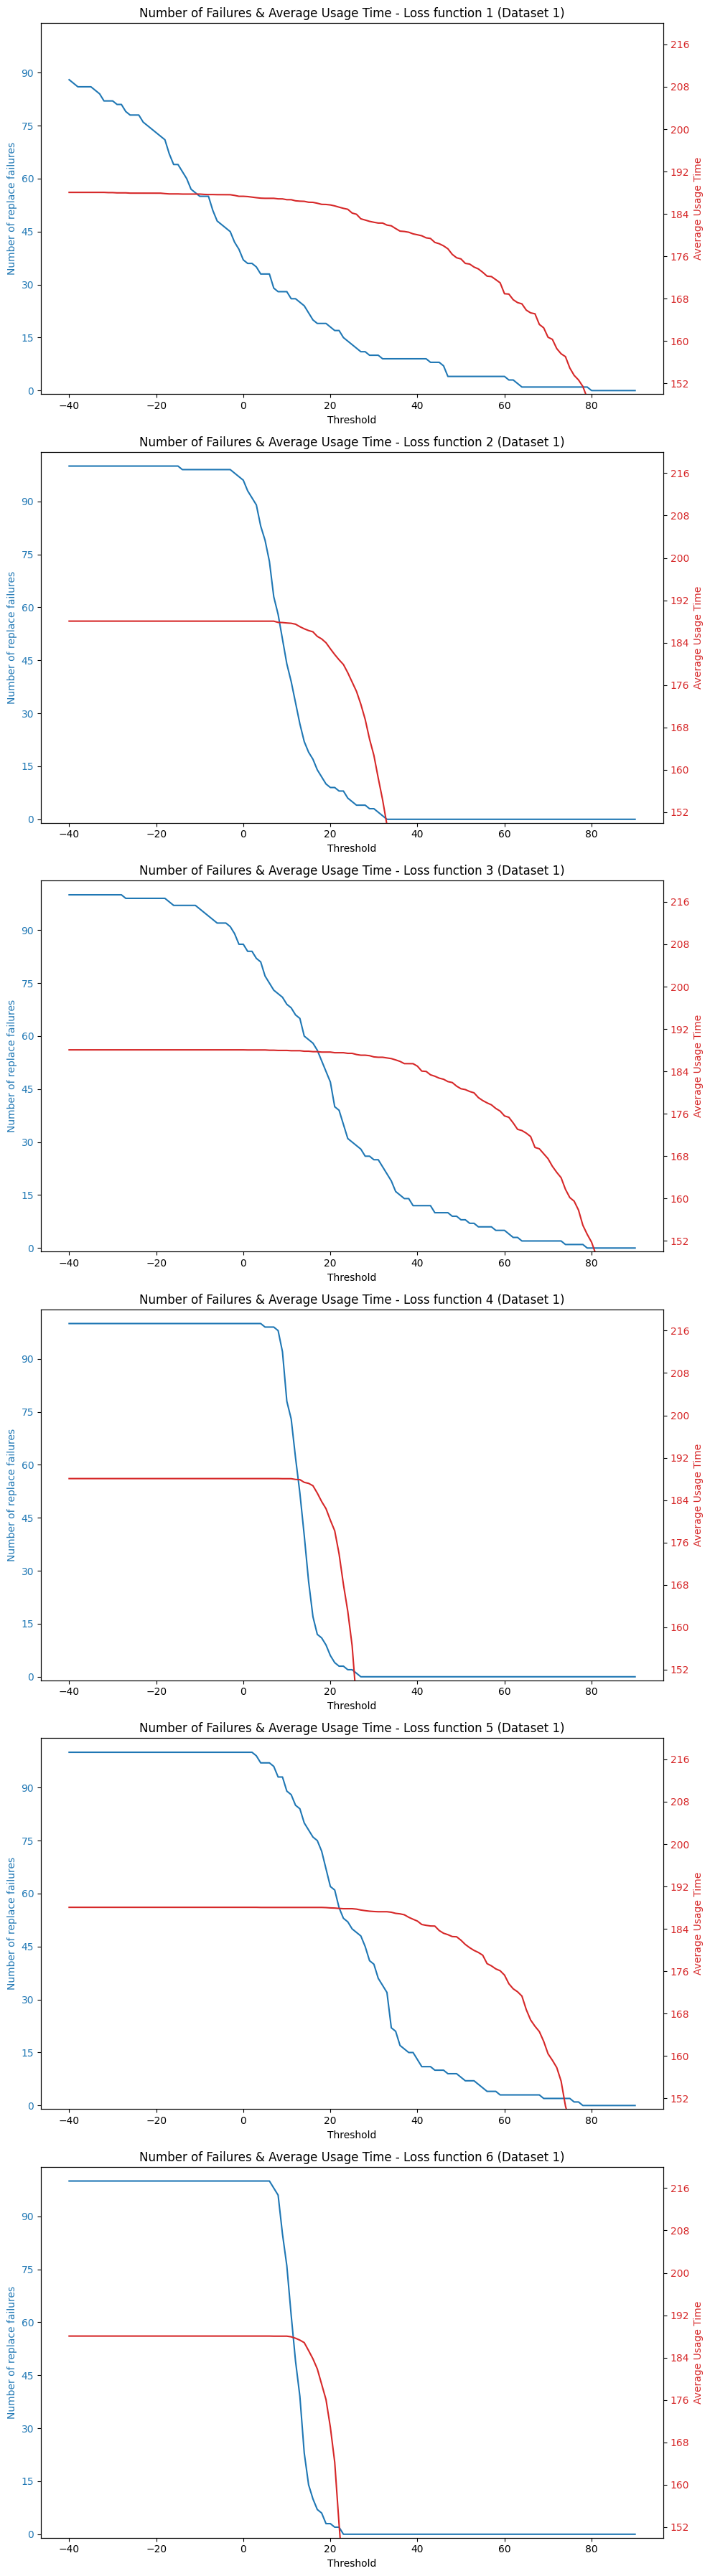

In [45]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Number of failures)
    color = 'tab:blue'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Number of replace failures', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Number of replace failures'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax1.set_ylim(-1,104) ### for Dataset1
    #ax1.set_ylim(-5,270) ### for Dataset2
    #ax1.set_ylim(-1,104) ### for Dataset3
    #ax1.set_ylim(-5,260) ### for Dataset4

    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(135,220) ### for Dataset2
    #ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(180,260) ### for Dataset4

    # 그래프 제목 설정
    ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 2)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Number of Failures & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

Average Cost

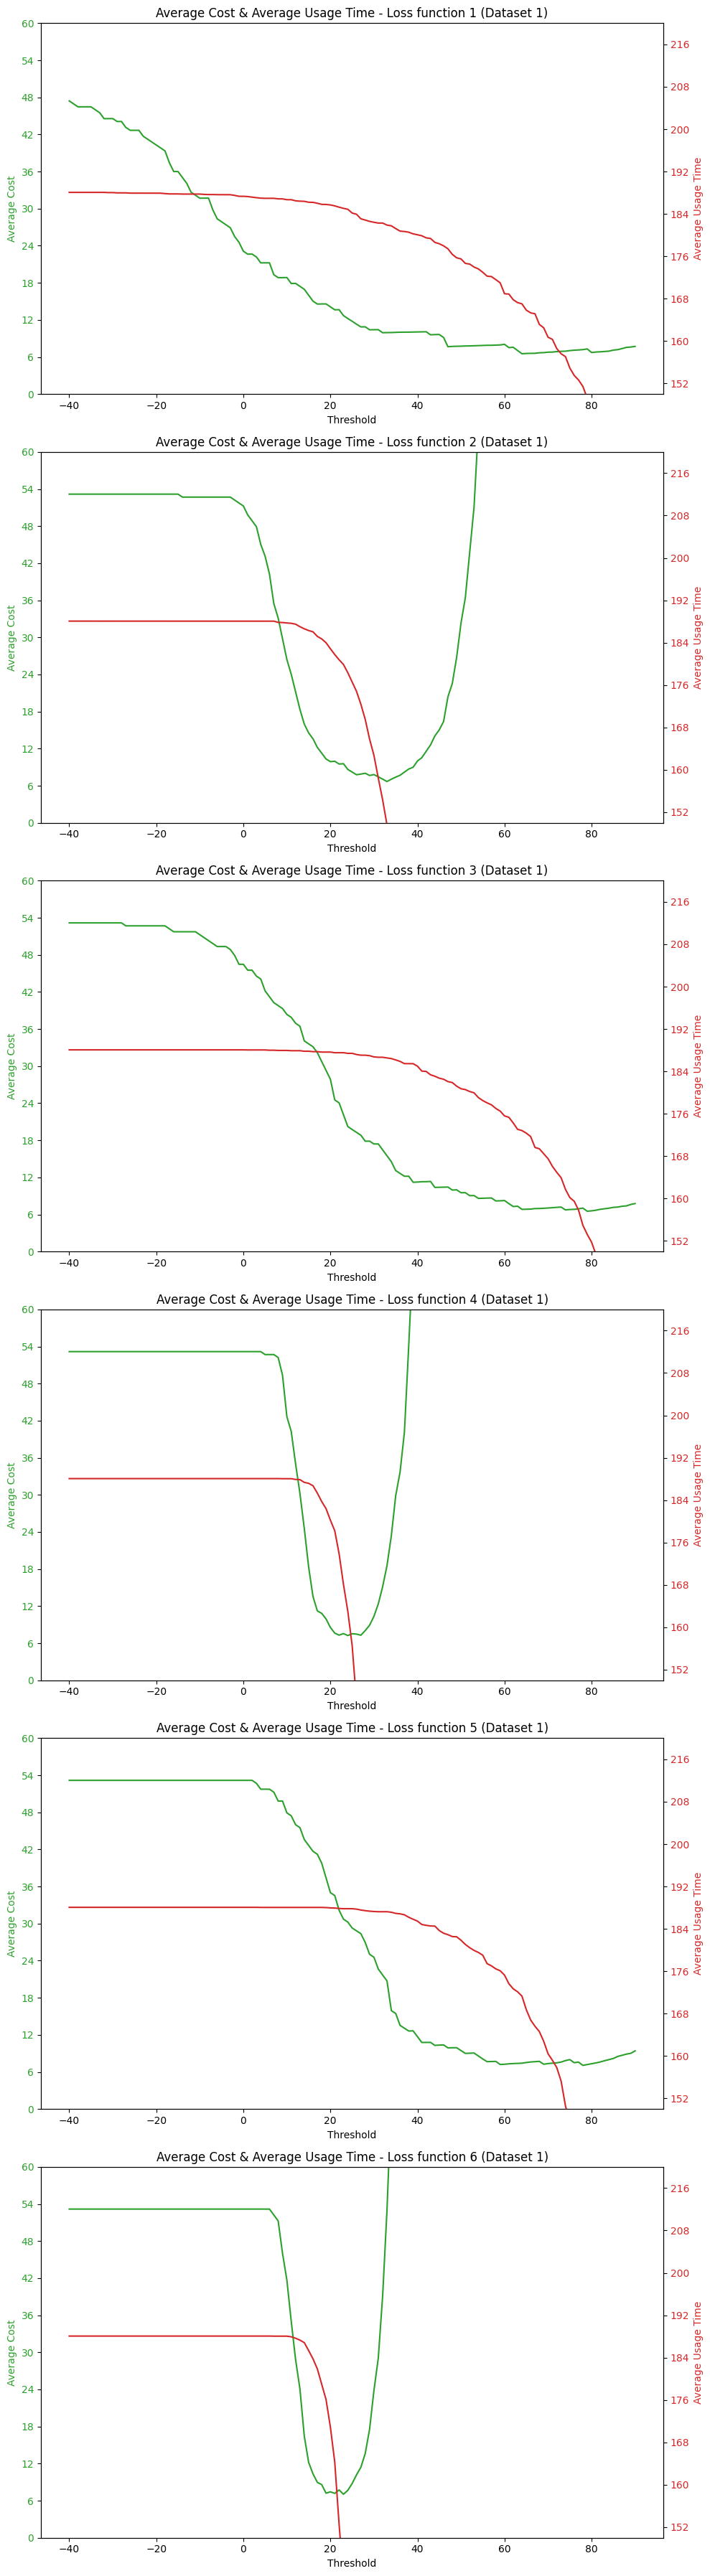

In [46]:
fig, axs = plt.subplots(len(full_nan_counts_and_cost_df_list), 1, figsize=(10, 6*len(full_nan_counts_and_cost_df_list)))

# 데이터프레임들을 저장한 리스트인 nan_counts_and_cost_df_list 내의 각 데이터프레임에 대해 반복 수행
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list, start=1):
    ax1 = axs[i-1]

    # 왼쪽 Y축 그래프 (Average Cost)
    color = 'tab:green'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Average Cost', color=color)
    ax1.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Total Cost'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax1.set_ylim(0,60) ### for dataset1
    #ax1.set_ylim(0,60) ### for dataset2
    #ax1.set_ylim(0,60) ### for dataset3
    #ax1.set_ylim(0,60) ### for dataset4
    """
    # 오른쪽 Y축 그래프 (Total Number of Engines Used)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Total Number of Engines Used', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Last index'] + 1, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(75,100)
    """
    # 오른쪽 Y축 그래프 (Average Usage Time)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average Usage Time', color=color)
    ax2.plot(full_nan_counts_and_cost_df['Threshold'], full_nan_counts_and_cost_df['Average usage time'], color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))  # 눈금을 정수로 표시
    ax2.set_ylim(150,220) ### for Dataset1
    #ax2.set_ylim(0,220) ### for Dataset2
    #ax2.set_ylim(190,260) ### for Dataset3
    #ax2.set_ylim(-0.5,260) ### for Dataset4

    # 그래프 제목 설정
    ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 1)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 2)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 3)')
    #ax1.set_title(f'Average Cost & Average Usage Time - Loss function {i} (Dataset 4)')

# 그래프 보이기
plt.tight_layout()  # subplot 간격 조정
plt.show()

**Scatter Plot - (Number of Failures vs. Average usage time)**

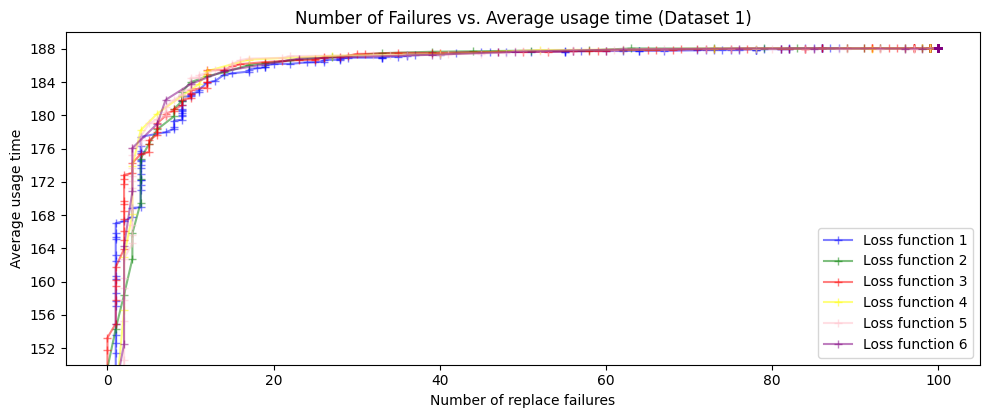

In [47]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(10, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):

    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'],
        '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(150,190) ### for dataset1
#ax.set_ylim(135,220) ### for dataset2
#ax.set_ylim(190,248) ### for dataset3
#ax.set_ylim(180,260) ### for dataset4

ax.set_xlim(-5,105) ### for dataset1,3
#ax.set_xlim(-5,265) ### for dataset2
#ax.set_xlim(-5,255) ### for dataset4

# Set aspect ratio to make the plot square
ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

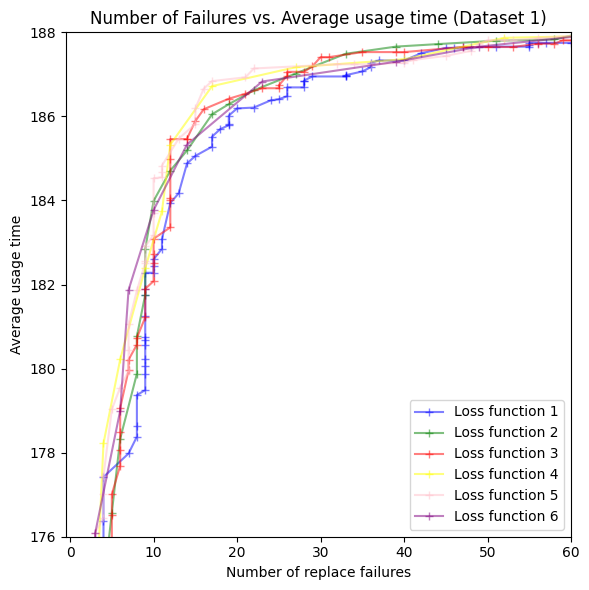

In [48]:
# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=f'Loss function {i + 1}',
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 2)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 3)')
#ax.set_title('Number of Failures vs. Average usage time (Dataset 4)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1
#ax.set_ylim(172,205) ### for dataset2
#ax.set_ylim(226,240) ### for dataset3
#ax.set_ylim(190,237) ### for dataset4
ax.set_xlim(-0.5,60)

# Set aspect ratio to make the plot square
#ax.set_aspect('equal')

# Show the plot
plt.tight_layout()
plt.show()

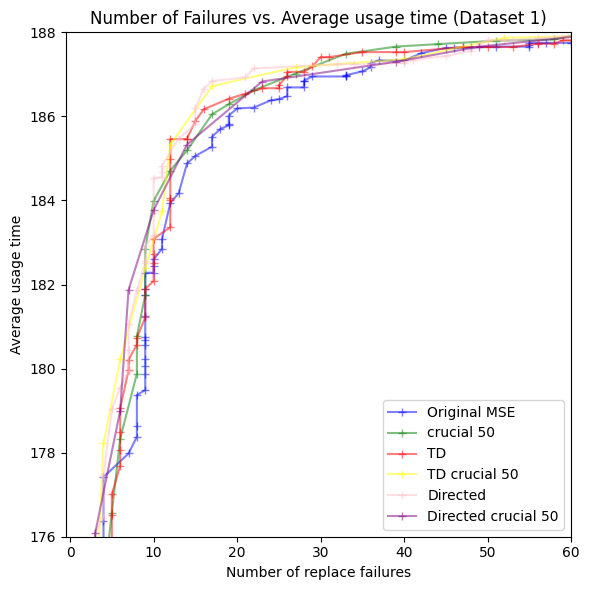

In [49]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, full_nan_counts_and_cost_df in enumerate(full_nan_counts_and_cost_df_list):
    ax.plot(
        full_nan_counts_and_cost_df['Number of replace failures'],
        full_nan_counts_and_cost_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

# 반복 시작 (나중에 최적화)

2번 샘플에 대해 코드 실행 (계속 반복)

In [50]:
train = sampled_data_list[1][0].copy()
valid = sampled_data_list[1][1].copy()
full_data = sampled_data_list[1][2].copy()

In [51]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [52]:
drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

In [53]:
X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

In [54]:
# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


train set RMSE:36.827793812693514, R2:0.6256993496711591
valid set RMSE:52.22792663859327, R2:0.48163254101686326
full data set RMSE:46.158359857118654, R2:0.5347273142230053
train set RMSE:71.66038917540646, R2:-0.4171881115940075
valid set RMSE:92.24151191350322, R2:-0.6169067914845812
full data set RMSE:82.50950149023014, R2:-0.4866705784052039
[[ 55.74342644]
 [  0.        ]
 [-20.60483723]
 [ -7.22362785]
 [-12.21778293]
 [  0.        ]
 [  2.80075404]
 [ 45.76804194]
 [ -1.62140621]
 [-28.29599081]
 [  0.        ]
 [-27.28440927]
 [ 34.99153972]
 [  3.15314899]
 [-31.85920542]
 [-10.21269493]
 [  0.        ]
 [ -7.87717189]
 [  0.        ]
 [  0.        ]
 [ 32.99020256]
 [ 32.18534002]]
(22, 1)
train set RMSE:39.007862433580044, R2:0.5800733084145954
valid set RMSE:54.120974614845, R2:0.4433741424196249
full data set RMSE:48.64274023628138, R2:0.4832947368568745
[[10.09398188]
 [ 0.        ]
 [-2.54106329]
 [ 0.62126595]
 [-2.28961311]
 [ 0.        ]
 [10.09398188]
 [12.01750474

In [55]:
X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])

Merged full DataFrame 1:
       unit_number  time_cycles  predicted RUL  RUL
0               1           40     140.402865  150
1               1           48     132.151303  142
2               1           61     134.577272  129
3               1          114     118.511376   76
4               1          115     114.715542   75
...           ...          ...            ...  ...
2058          100          154      44.076291   46
2059          100          155      47.265084   45
2060          100          178      23.779887   22
2061          100          187      12.947082   13
2062          100          200     -29.121076    0

[2063 rows x 4 columns]
Merged full DataFrame 2:
       unit_number  time_cycles  predicted RUL  RUL
0               1           40      56.675968  150
1               1           48      51.212635  142
2               1           61      53.183602  129
3               1          114      45.012954   76
4               1          115      46.194957   75
...  

In [56]:
# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)

DataFrame for merged_valid_df 1:
      Threshold  Number of replace failures  Total Cost  Average usage time
0          -40                          78   42.938216              186.78
1          -39                          78   42.938216              186.78
2          -38                          76   41.974515              186.78
3          -37                          75   41.501553              186.74
4          -36                          75   41.501553              186.74
..         ...                         ...         ...                 ...
126         86                           0    8.149295              122.71
127         87                           0    8.265829              120.98
128         88                           0    8.468835              118.08
129         89                           0    8.612523              116.11
130         90                           0    8.791982              113.74

[131 rows x 4 columns]
DataFrame for merged_valid_df 2:
      Thr

In [57]:
full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

3번째 반복

In [58]:
train = sampled_data_list[2][0].copy()
valid = sampled_data_list[2][1].copy()
full_data = sampled_data_list[2][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.60326264656826, R2:0.6266117857417515
valid set RMSE:50.24790861244218, R2:0.4960474274129171
full data set RMSE:45.70326032242603, R2:0.5792267379555294
train set RMSE:74.43593378075421, R2:-0.4631027651862678
valid set RMSE:92.50931640186673, R2:-0.7081445867041762
full data set RMSE:85.38264387167624, R2:-0.4685643028605935
[[ 58.57123229]
 [  0.        ]
 [-14.61551965]
 [ -8.77084182]
 [-17.76854179]
 [  0.        ]
 [  5.44267329]
 [ 32.70939508]
 [  9.19373442]
 [-29.8728294 ]
 [  0.        ]
 [-29.03141796]
 [ 42.14667622]
 [  5.12394   ]
 [-24.28033302]
 [-13.99233646]
 [  0.        ]
 [ -9.47348886]
 [  0.        ]
 [  0.        ]
 [ 36.0875541 ]
 [ 30.81826881]]
(22, 1)
train set RMSE:39.68418210411093, R2:0.5841426161223081
valid set RMSE:52.31594838886823, R2:0.45371171058464943
full data set RMSE:48.94170986000498, R2:0.5174836362049788
[[10.86626931]
 [ 0.        ]
 [-2.58352257]
 [-1.68639283]
 [-6.35270502]
 [ 0.        ]
 [ 9.43966279]
 [ 9.82850022]

4번째 반복

In [59]:
train = sampled_data_list[3][0].copy()
valid = sampled_data_list[3][1].copy()
full_data = sampled_data_list[3][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.5032777995193, R2:0.6286745149724957
valid set RMSE:46.63829430743377, R2:0.5748903926833043
full data set RMSE:46.313984090050766, R2:0.561415404486781
train set RMSE:74.27301382198256, R2:-0.4563923768998923
valid set RMSE:91.1861955480479, R2:-0.6250764461456184
full data set RMSE:84.66271058490108, R2:-0.46559315261709844
[[ 62.02034933]
 [  0.        ]
 [ -9.28684754]
 [ -5.44349514]
 [-11.9746569 ]
 [  0.        ]
 [  0.96831889]
 [ 42.29714146]
 [ -0.74780934]
 [-30.59377488]
 [  0.        ]
 [-21.36934075]
 [ 45.7793893 ]
 [ -3.18419044]
 [-24.51235916]
 [-17.25660724]
 [  0.        ]
 [-15.51201302]
 [  0.        ]
 [  0.        ]
 [ 26.3321952 ]
 [ 28.54688135]]
(22, 1)
train set RMSE:39.53308063700746, R2:0.5873920231331275
valid set RMSE:49.681050517903586, R2:0.5176112802262512
full data set RMSE:48.93316685570766, R2:0.5104063952965132
[[11.08455371]
 [ 0.        ]
 [ 0.81380668]
 [-2.15875554]
 [-2.89130561]
 [ 0.        ]
 [ 8.9581643 ]
 [ 8.17280639]


5번째 반복

In [60]:
train = sampled_data_list[4][0].copy()
valid = sampled_data_list[4][1].copy()
full_data = sampled_data_list[4][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:34.93218819270365, R2:0.6702418090564275
valid set RMSE:52.00131506463168, R2:0.4826461362655975
full data set RMSE:46.46352868573596, R2:0.5257825171502686
train set RMSE:69.98492807252235, R2:-0.3235886997562454
valid set RMSE:89.17136581298259, R2:-0.5212825400051198
full data set RMSE:79.46809820713479, R2:-0.3871991752113033
[[ 56.3519449 ]
 [  0.        ]
 [-13.3327315 ]
 [ -7.92406548]
 [-18.53558967]
 [  0.        ]
 [  6.23619261]
 [ 47.79794908]
 [ -2.23520501]
 [-22.33825759]
 [  0.        ]
 [-25.855941  ]
 [ 35.37964343]
 [  0.95399766]
 [-27.42358638]
 [-13.29688908]
 [  0.        ]
 [-13.57639046]
 [  0.        ]
 [  0.        ]
 [ 27.88187908]
 [ 27.95270158]]
(22, 1)
train set RMSE:37.26263306694658, R2:0.6247755848394521
valid set RMSE:53.58584475981132, R2:0.4506372521547841
full data set RMSE:48.61529704388042, R2:0.4808425750515142
[[ 9.91934092]
 [ 0.        ]
 [-1.49581227]
 [-1.95203863]
 [-3.11038069]
 [ 0.        ]
 [ 8.46686149]
 [ 9.78945216]


6번째 반복

In [61]:
train = sampled_data_list[5][0].copy()
valid = sampled_data_list[5][1].copy()
full_data = sampled_data_list[5][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.92192732471241, R2:0.6245008210908786
valid set RMSE:54.74503425421396, R2:0.5057672805425353
full data set RMSE:48.51100330457895, R2:0.5180497245178524
train set RMSE:69.87459715254161, R2:-0.34486564511876283
valid set RMSE:93.04034395675997, R2:-0.427528029001234
full data set RMSE:82.58141988126835, R2:-0.3966462213995572
[[ 54.12340766]
 [  0.        ]
 [ -9.99870968]
 [-14.59440344]
 [-22.16969709]
 [  0.        ]
 [  6.16725786]
 [ 40.39111095]
 [  0.89332974]
 [-25.48592461]
 [  0.        ]
 [-20.71738419]
 [ 43.08800795]
 [ -3.55371951]
 [-23.91806425]
 [ -9.06599922]
 [  0.        ]
 [ -4.70196568]
 [  0.        ]
 [  0.        ]
 [ 31.05645396]
 [ 33.02225351]]
(22, 1)
train set RMSE:38.85928464784647, R2:0.5840607844111014
valid set RMSE:57.97704748561118, R2:0.44568807786231124
full data set RMSE:51.162857354268965, R2:0.4639179059642712
[[10.68210605]
 [ 0.        ]
 [-2.18940272]
 [-3.32655981]
 [-4.51937032]
 [ 0.        ]
 [10.68210605]
 [11.67054679

7번째 반복

In [62]:
train = sampled_data_list[6][0].copy()
valid = sampled_data_list[6][1].copy()
full_data = sampled_data_list[6][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.63778120912838, R2:0.6229341490120359
valid set RMSE:47.77397322188093, R2:0.554348328676048
full data set RMSE:49.352007441491445, R2:0.5032039857030681
train set RMSE:73.21166194657054, R2:-0.42669029492939314
valid set RMSE:87.3886981840252, R2:-0.4911569450122104
full data set RMSE:81.34503366773073, R2:-0.3496791657001064
[[ 64.65488811]
 [  0.        ]
 [ -8.04641618]
 [ -6.30985139]
 [-25.5138011 ]
 [  0.        ]
 [  4.7436185 ]
 [ 32.21676362]
 [ -3.87781229]
 [-30.27292651]
 [  0.        ]
 [-19.67822478]
 [ 46.26172443]
 [  0.06930802]
 [-23.18534226]
 [-15.40063378]
 [  0.        ]
 [ -5.60629979]
 [  0.        ]
 [  0.        ]
 [ 33.22373862]
 [ 23.61957517]]
(22, 1)
train set RMSE:39.76919969962824, R2:0.579018628594622
valid set RMSE:50.53753636966216, R2:0.5012981838864566
full data set RMSE:51.31025207963111, R2:0.46299694790992285
[[10.37634641]
 [ 0.        ]
 [-2.03366989]
 [-1.90125789]
 [-3.56749291]
 [ 0.        ]
 [10.37634641]
 [10.79154518]


8번째 반복

In [63]:
train = sampled_data_list[7][0].copy()
valid = sampled_data_list[7][1].copy()
full_data = sampled_data_list[7][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.800566063845444, R2:0.6329552189869925
valid set RMSE:46.8860178331512, R2:0.5480458356264686
full data set RMSE:47.64317735075925, R2:0.5344682943384882
train set RMSE:71.90115650708016, R2:-0.40114088884527055
valid set RMSE:84.14602789443853, R2:-0.45571023505368546
full data set RMSE:81.60057673420572, R2:-0.3656338930614873
[[ 58.96253626]
 [  0.        ]
 [-14.78019621]
 [ -5.89060596]
 [-18.86380441]
 [  0.        ]
 [ 10.0673531 ]
 [ 32.76359034]
 [ -4.26305385]
 [-26.90872191]
 [  0.        ]
 [-20.51463716]
 [ 44.50012415]
 [ -2.82353059]
 [-23.01954831]
 [-20.91294567]
 [  0.        ]
 [ -8.52473259]
 [  0.        ]
 [  0.        ]
 [ 27.91165931]
 [ 30.77024391]]
(22, 1)
train set RMSE:38.823895453288586, R2:0.5914847506181424
valid set RMSE:49.26588533620954, R2:0.5010003063125283
full data set RMSE:50.40182865608072, R2:0.478996767906936
[[11.13701477]
 [ 0.        ]
 [-0.63500904]
 [-1.28567755]
 [-5.14114522]
 [ 0.        ]
 [ 8.65097042]
 [ 8.7275049 

9번째 반복

In [64]:
train = sampled_data_list[8][0].copy()
valid = sampled_data_list[8][1].copy()
full_data = sampled_data_list[8][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.45187875200075, R2:0.6360995720947207
valid set RMSE:48.88660427500995, R2:0.5416054683781224
full data set RMSE:45.99936907691185, R2:0.5515464061844777
train set RMSE:73.57527542126951, R2:-0.4825403599693472
valid set RMSE:91.64445898308448, R2:-0.6109130814937866
full data set RMSE:82.21277223578196, R2:-0.432492459955943
[[ 58.09593017]
 [  0.        ]
 [-10.39276808]
 [-11.4183123 ]
 [-23.97417703]
 [  0.        ]
 [  8.42188536]
 [ 31.33466105]
 [  5.73390164]
 [-27.9624648 ]
 [  0.        ]
 [-27.88995418]
 [ 47.64165138]
 [  6.00040787]
 [-26.3228508 ]
 [-10.7340912 ]
 [  0.        ]
 [ -8.99425927]
 [  0.        ]
 [  0.        ]
 [ 23.91834961]
 [ 35.24967679]]
(22, 1)
train set RMSE:38.624563896847704, R2:0.5914267680397732
valid set RMSE:51.52339753735827, R2:0.49082312473957557
full data set RMSE:48.57020098897097, R2:0.5000189318534143
[[10.46404673]
 [ 0.        ]
 [-1.26371207]
 [-2.51414713]
 [-3.15042118]
 [ 0.        ]
 [10.46404673]
 [ 7.11899426]

10번째 반복

In [65]:
train = sampled_data_list[9][0].copy()
valid = sampled_data_list[9][1].copy()
full_data = sampled_data_list[9][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.69024682114529, R2:0.6301409146104253
valid set RMSE:51.61901107780767, R2:0.496836444522593
full data set RMSE:46.28460690070805, R2:0.5625914196590052
train set RMSE:74.16333418187445, R2:-0.5111706748603575
valid set RMSE:91.98823880405729, R2:-0.5979177654391667
full data set RMSE:85.04711792645615, R2:-0.47683963927404327
[[ 66.44076561]
 [  0.        ]
 [ -4.59800789]
 [ -7.46587654]
 [-16.98848423]
 [  0.        ]
 [ -3.16988036]
 [ 34.25829045]
 [ -7.73314517]
 [-27.62266585]
 [  0.        ]
 [-21.02940792]
 [ 47.78354122]
 [ -2.60859276]
 [-27.49337063]
 [-13.56086357]
 [  0.        ]
 [-12.45688825]
 [  0.        ]
 [  0.        ]
 [ 27.67812634]
 [ 26.05366416]]
(22, 1)
train set RMSE:38.90843940553661, R2:0.584067699229623
valid set RMSE:53.72841492116571, R2:0.4548727729904243
full data set RMSE:49.69298207433669, R2:0.49579835538527683
[[ 9.75611107]
 [ 0.        ]
 [-0.8847074 ]
 [-3.13277146]
 [-0.27763758]
 [ 0.        ]
 [ 9.75611107]
 [10.27669637]


11

In [66]:
train = sampled_data_list[10][0].copy()
valid = sampled_data_list[10][1].copy()
full_data = sampled_data_list[10][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.35631645297816, R2:0.6418337818809852
valid set RMSE:47.56019740269197, R2:0.5455778793338741
full data set RMSE:48.12111717211134, R2:0.5236029459184118
train set RMSE:72.41963273718503, R2:-0.42114210715607747
valid set RMSE:88.23194369106035, R2:-0.5639535857815621
full data set RMSE:85.33280673798464, R2:-0.49806178591463657
[[ 56.89750585]
 [  0.        ]
 [ -8.58772347]
 [-11.38820465]
 [-18.32683382]
 [  0.        ]
 [  3.62067194]
 [ 41.18898179]
 [  1.19047503]
 [-31.41796951]
 [  0.        ]
 [-27.03622539]
 [ 43.5380229 ]
 [ -1.60776274]
 [-33.09853485]
 [-13.05088812]
 [  0.        ]
 [ -6.02429374]
 [  0.        ]
 [  0.        ]
 [ 32.71886974]
 [ 26.54788652]]
(22, 1)
train set RMSE:38.40792383411382, R2:0.6002701921993764
valid set RMSE:49.63947323501921, R2:0.5049757260825576
full data set RMSE:50.68347831335928, R2:0.4715176484712912
[[ 9.83565013]
 [ 0.        ]
 [-1.94004475]
 [ 0.41015827]
 [-2.82207485]
 [ 0.        ]
 [ 8.1954364 ]
 [10.0378919 

In [67]:
train = sampled_data_list[11][0].copy()
valid = sampled_data_list[11][1].copy()
full_data = sampled_data_list[11][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:39.278157081979025, R2:0.5988694508673014
valid set RMSE:53.14122132575034, R2:0.4901831186535768
full data set RMSE:45.4030029713901, R2:0.5682169563075918
train set RMSE:77.9079504080132, R2:-0.5781456808275183
valid set RMSE:97.81594828576183, R2:-0.7273107994353196
full data set RMSE:85.00460166090542, R2:-0.5134960787865344
[[ 64.26940744]
 [  0.        ]
 [-10.11816977]
 [-15.17376179]
 [-17.19374097]
 [  0.        ]
 [  8.24108512]
 [ 30.57450577]
 [ -3.08571163]
 [-33.1190378 ]
 [  0.        ]
 [-19.21367615]
 [ 41.68962703]
 [ -4.40260409]
 [-28.84957908]
 [-13.87873248]
 [  0.        ]
 [ -9.74984401]
 [  0.        ]
 [  0.        ]
 [ 32.87198532]
 [ 27.09856183]]
(22, 1)
train set RMSE:41.464278010930094, R2:0.5529750655182157
valid set RMSE:55.85441934915444, R2:0.43679535002770575
full data set RMSE:48.580831882267866, R2:0.5056593531850322
[[ 9.90385186]
 [ 0.        ]
 [-0.31696927]
 [-2.71742159]
 [-2.13096479]
 [ 0.        ]
 [ 9.46678022]
 [10.14516126

In [68]:
train = sampled_data_list[12][0].copy()
valid = sampled_data_list[12][1].copy()
full_data = sampled_data_list[12][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.91237715590771, R2:0.5972046334167482
valid set RMSE:50.322646770439896, R2:0.5184670830723761
full data set RMSE:48.38109459720501, R2:0.530695678467731
train set RMSE:77.11684573129713, R2:-0.5820035581191336
valid set RMSE:92.97164137539804, R2:-0.6436147366299623
full data set RMSE:83.98779561343932, R2:-0.4142804535176303
[[ 61.44670355]
 [  0.        ]
 [ -5.54237444]
 [ -6.92624028]
 [-18.82505997]
 [  0.        ]
 [  4.10419195]
 [ 43.86171526]
 [ -2.28808158]
 [-23.49303463]
 [  0.        ]
 [-27.61013914]
 [ 43.6288337 ]
 [  2.84737484]
 [-20.32937272]
 [-19.31885206]
 [  0.        ]
 [ -8.71497656]
 [  0.        ]
 [  0.        ]
 [ 23.38828241]
 [ 26.26163473]]
(22, 1)
train set RMSE:40.818279754162404, R2:0.5567810336529744
valid set RMSE:53.69964256577431, R2:0.4516702369520884
full data set RMSE:51.053244590946576, R2:0.47742350721245064
[[ 9.57233113]
 [ 0.        ]
 [-1.17532867]
 [-3.1854232 ]
 [-2.73103979]
 [ 0.        ]
 [ 9.57233113]
 [ 9.4459024

In [69]:
train = sampled_data_list[13][0].copy()
valid = sampled_data_list[13][1].copy()
full_data = sampled_data_list[13][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.53797744549537, R2:0.6412135195570052
valid set RMSE:53.62902946682005, R2:0.46890464435996027
full data set RMSE:47.23119388091613, R2:0.5251294269337389
train set RMSE:73.47839359157392, R2:-0.45099651461476853
valid set RMSE:88.18311585626483, R2:-0.43596385628624823
full data set RMSE:81.60022755312643, R2:-0.4174252026886993
[[ 58.71273106]
 [  0.        ]
 [ -8.46083999]
 [-13.99542916]
 [-24.56205535]
 [  0.        ]
 [  1.58226152]
 [ 36.52016079]
 [  5.70509474]
 [-24.8444268 ]
 [  0.        ]
 [-30.73673876]
 [ 51.8510465 ]
 [  1.92807221]
 [-23.08482779]
 [-10.25053091]
 [  0.        ]
 [ -4.30335161]
 [  0.        ]
 [  0.        ]
 [ 24.99104943]
 [ 25.75371138]]
(22, 1)
train set RMSE:38.72739209540503, R2:0.5969271294663325
valid set RMSE:54.34971618697825, R2:0.4545346225860417
full data set RMSE:49.007763064449975, R2:0.4887336962472235
[[10.36516584]
 [ 0.        ]
 [-0.63050578]
 [-0.26375781]
 [-3.56814906]
 [ 0.        ]
 [ 9.11480904]
 [ 9.933450

In [70]:
train = sampled_data_list[14][0].copy()
valid = sampled_data_list[14][1].copy()
full_data = sampled_data_list[14][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.21613574281728, R2:0.6204525017499691
valid set RMSE:51.10390723127284, R2:0.5189573248269177
full data set RMSE:46.909738808017764, R2:0.5392598135506136
train set RMSE:74.51580946589664, R2:-0.5215997424029635
valid set RMSE:93.36208251425532, R2:-0.6055227163097519
full data set RMSE:86.58464826404298, R2:-0.5696826507385135
[[ 58.17317505]
 [  0.        ]
 [-21.50869831]
 [ -7.69268022]
 [-16.41567355]
 [  0.        ]
 [  2.68483607]
 [ 38.78467178]
 [ -1.21496097]
 [-28.37066688]
 [  0.        ]
 [-24.58046662]
 [ 41.56404083]
 [  6.46038789]
 [-16.72682354]
 [-13.54345215]
 [  0.        ]
 [ -8.20945284]
 [  0.        ]
 [  0.        ]
 [ 31.32874044]
 [ 26.43335195]]
(22, 1)
train set RMSE:39.39030769498688, R2:0.5748107013000809
valid set RMSE:54.09923792668022, R2:0.4609144526726928
full data set RMSE:50.027614336264286, R2:0.47597784295222423
[[ 9.66799295]
 [ 0.        ]
 [-2.5154659 ]
 [ 0.39131866]
 [-1.3917561 ]
 [ 0.        ]
 [ 9.66799295]
 [ 9.2126071

In [71]:
train = sampled_data_list[15][0].copy()
valid = sampled_data_list[15][1].copy()
full_data = sampled_data_list[15][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.345183441173496, R2:0.6041402458050829
valid set RMSE:50.832591071163755, R2:0.521044084249193
full data set RMSE:46.06256377093257, R2:0.5531338385971455
train set RMSE:74.53010325258965, R2:-0.49548877271271996
valid set RMSE:92.33995303057836, R2:-0.5804848804583309
full data set RMSE:84.15992627000739, R2:-0.49173592574319835
[[ 59.05382604]
 [  0.        ]
 [-15.40913869]
 [ -8.39027539]
 [-18.27313172]
 [  0.        ]
 [  7.25349356]
 [ 36.96318619]
 [  5.1947384 ]
 [-37.65635963]
 [  0.        ]
 [-25.65641266]
 [ 48.36549119]
 [  4.69017475]
 [-26.65581065]
 [-13.54538927]
 [  0.        ]
 [ -8.54256496]
 [  0.        ]
 [  0.        ]
 [ 23.32125664]
 [ 28.70659224]]
(22, 1)
train set RMSE:40.43820265169276, R2:0.5597459094272925
valid set RMSE:52.739551120374855, R2:0.4844344322591442
full data set RMSE:48.64010516697861, R2:0.5017236586658929
[[10.40393234]
 [ 0.        ]
 [-1.27842843]
 [-1.97411118]
 [-4.69439859]
 [ 0.        ]
 [10.40393234]
 [ 9.569517

In [72]:
train = sampled_data_list[16][0].copy()
valid = sampled_data_list[16][1].copy()
full_data = sampled_data_list[16][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.17765128068078, R2:0.6204800014888687
valid set RMSE:51.040717486071095, R2:0.506113473777233
full data set RMSE:49.022759296849024, R2:0.5034498174292377
train set RMSE:74.87276268000734, R2:-0.45970121158368515
valid set RMSE:91.94321221184522, R2:-0.6026289443733548
full data set RMSE:86.72709369104565, R2:-0.5540937979744285
[[ 60.58621746]
 [  0.        ]
 [-15.18675952]
 [ -3.32520241]
 [-18.8887132 ]
 [  0.        ]
 [  1.88907815]
 [ 47.40385604]
 [  3.53052172]
 [-30.05890999]
 [  0.        ]
 [-26.14652124]
 [ 51.5253452 ]
 [ -3.89924461]
 [-29.23927664]
 [-15.49339572]
 [  0.        ]
 [ -9.06537133]
 [  0.        ]
 [  0.        ]
 [ 23.92521089]
 [ 21.6810339 ]]
(22, 1)
train set RMSE:40.36750904353111, R2:0.5756930409782235
valid set RMSE:52.41322866993959, R2:0.47919461835364074
full data set RMSE:49.9269308505143, R2:0.48496424433001617
[[10.38218366]
 [ 0.        ]
 [-3.98873341]
 [-2.00111147]
 [-3.26119349]
 [ 0.        ]
 [10.38218366]
 [ 9.8206818

In [73]:
train = sampled_data_list[17][0].copy()
valid = sampled_data_list[17][1].copy()
full_data = sampled_data_list[17][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:38.0584891176411, R2:0.6084641042156447
valid set RMSE:51.99103246171963, R2:0.4909851957523004
full data set RMSE:47.02273269577738, R2:0.5133121366103177
train set RMSE:73.65326512165005, R2:-0.4664001831272109
valid set RMSE:91.79197349176063, R2:-0.5866566049823871
full data set RMSE:84.416687530075, R2:-0.5685248409570722
[[ 55.213012  ]
 [  0.        ]
 [-14.32950405]
 [ -4.44062378]
 [-10.29601156]
 [  0.        ]
 [  6.84125642]
 [ 36.78369481]
 [  2.24212701]
 [-30.33449124]
 [  0.        ]
 [-28.21096122]
 [ 45.08931992]
 [ -0.77154756]
 [-28.97322071]
 [-13.04747209]
 [  0.        ]
 [-14.80962216]
 [  0.        ]
 [  0.        ]
 [ 27.24115398]
 [ 30.65686611]]
(22, 1)
train set RMSE:39.934879847312885, R2:0.5689047260273326
valid set RMSE:54.401631528861934, R2:0.44268930312565824
full data set RMSE:49.21102937559778, R2:0.4669601392395405
[[10.13943954]
 [ 0.        ]
 [-1.94977456]
 [-2.56264449]
 [-3.100335  ]
 [ 0.        ]
 [10.13943954]
 [ 8.9008378 ]


In [74]:
train = sampled_data_list[18][0].copy()
valid = sampled_data_list[18][1].copy()
full_data = sampled_data_list[18][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:36.384802234975105, R2:0.6305353216268562
valid set RMSE:47.73965805046467, R2:0.5443986768368834
full data set RMSE:45.96236573948815, R2:0.5633518282252712
train set RMSE:72.15420514404428, R2:-0.4529684413080053
valid set RMSE:88.20344104644502, R2:-0.5552400291467563
full data set RMSE:84.01145149754481, R2:-0.45882727356805497
[[ 57.73974689]
 [  0.        ]
 [-14.2471683 ]
 [ -7.33747628]
 [-24.99741734]
 [  0.        ]
 [  9.47926877]
 [ 31.93562041]
 [ -0.58082357]
 [-30.61607534]
 [  0.        ]
 [-27.54248186]
 [ 45.23230626]
 [ -1.32989382]
 [-23.24626132]
 [ -8.04265499]
 [  0.        ]
 [ -8.19005021]
 [  0.        ]
 [  0.        ]
 [ 29.96337553]
 [ 27.39375769]]
(22, 1)
train set RMSE:38.523548760343395, R2:0.5858234920184351
valid set RMSE:48.50826429023246, R2:0.529610261542987
full data set RMSE:48.88555408172847, R2:0.5060443225431119
[[ 9.65945492]
 [ 0.        ]
 [-3.22531019]
 [-1.67436774]
 [-4.20023314]
 [ 0.        ]
 [ 9.65945492]
 [ 8.36501979

In [75]:
train = sampled_data_list[19][0].copy()
valid = sampled_data_list[19][1].copy()
full_data = sampled_data_list[19][2].copy()

train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

drop_labels = index_names+setting_names

# index_name을 split해서 보관해뒀다가 추후에 병합해줘야 RL에 적용할 수 있음
X_train_index_names = train[['unit_number', 'time_cycles']]
X_train = train.drop(columns=drop_labels).copy()
X_train, X_test, y_train, y_test = train_test_split(X_train, X_train['RUL'], test_size = 0.01, random_state = 42, shuffle = False)

# Valid 코드도 수정해야 LR 가능함. ################################
# Valid data : engine 71~100
X_valid_index_names = valid[['unit_number','time_cycles']]
y_valid = valid[['RUL']]
X_valid = valid.drop(columns=drop_labels).copy()

X_full_index_names = full_data[['unit_number','time_cycles']]
y_full = full_data[['RUL']]
X_full = full_data.drop(columns=drop_labels).copy()


# 스케일링
scaler = MinMaxScaler()  # MinMaxScaler

#Droping the target variable (True RUL)
X_train.drop(columns=['RUL'], inplace=True) # inplace -> true면 원본 삭제 (current option)  # inplace -> False면 원본은 유지

#Scaling X_train
X_train_s=scaler.fit_transform(X_train)

#Conserve only the last occurence of each unit to match the length of y_valid
#X_valid = valid.groupby('unit_number').last().reset_index().drop(columns=drop_labels)

X_valid.drop(columns=['RUL'], inplace=True)
X_valid_s = scaler.transform(X_valid)

X_full.drop(columns=['RUL'], inplace=True)
X_full_s = scaler.transform(X_full)
#scaling X_valid
#X_valid_s=scaler.fit_transform(X_valid)

#fit_transform() : for train data ; transform() : for test data

X_train_1=X_train
X_train_1_s=scaler.fit_transform(X_train_1) #scaling X_train_1

y_train_clip=y_train.clip(upper=195)  #Clipping y_train to have 195 as the maximum value (it means y = 197 -> y = 195)

X_valid_1=X_valid
X_valid_1_s=scaler.fit_transform(X_valid_1) #scaling X_valid_1

X_full_1=X_full
X_full_1_s=scaler.fit_transform(X_full_1) #scaling X_full_1

# 1. Original Linear Regression ####################################################
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_1, label='train')

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_1, label='valid')

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_1, label='full data')


# 2. Crucial moments loss function - Linear Regression ############################

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')


# 3. ##############################################################################
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_3, label='train')

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_3, label='valid')

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_3, label='full data')


# 4. ##############################################################################
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')


# 5. ##############################################################################
y_train_clip_float = y_train_clip.astype(np.float32) # penalty를 활용할 때 data type을 맞춰주기 위해 astype 활용.

# generate DirectedLinearRegression
lr5 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

# model compile
lr5.compile(optimizer='adam', loss=directed_mse_loss)

# fitting
lr5.fit(X_train_1_s, y_train_clip_float, epochs=1000, verbose=0)

y_lr_train_5 = lr5.predict(X_train_1_s)
y_lr_valid_5 = lr5.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_5 = lr5.predict(X_full_1_s) #Prediction on full data


# 6. ##############################################################################
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip_float[y_train_clip_float <= 50.0]

lr6 = models.Sequential([
    layers.Input(shape=(X_train_1_s.shape[1],)),
    layers.Dense(1)
])

lr6.compile(optimizer='adam', loss=directed_mse_loss)

lr6.fit(filtered_data, filtered_labels, epochs=1000, verbose=0) #Fitting

y_lr_train_6 = lr6.predict(X_train_1_s)
y_lr_valid_6 = lr6.predict(X_valid_1_s) #Prediction on validation data
y_lr_full_6 = lr6.predict(X_full_1_s) #Prediction on full data


X_valid_index_names = X_valid_index_names.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
X_full_index_names = X_full_index_names.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# loss function 별 dataframe들을 list로 저장 (full dataset만)
y_lr_full_dfs = [pd.DataFrame(y_lr_full_1, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_2, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_3, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_4, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_5, columns=['predicted RUL']),
                  pd.DataFrame(y_lr_full_6, columns=['predicted RUL'])]
merged_full_dfs = []

# 각 dataframe에 병합하고 출력
for i, y_lr_full_df in enumerate(y_lr_full_dfs, start=1):
    merged_full = pd.concat([X_full_index_names, y_lr_full_df, y_full], axis=1)
    merged_full_dfs.append(merged_full)
    print(f"Merged full DataFrame {i}:\n", merged_full)

# 각 threshold_value에 대한 dataframe을 담을 리스트를 생성.
full_by_threshold_dfs_list = []

# merged_full_dfs 리스트 내에 있는 각 데이터프레임에 대해 반복 수행
for merged_full_df in merged_full_dfs:
    full_by_threshold_dfs = []

    # threshold_value 별 처리.
    for threshold_value in threshold_values:

        cumulative_operation_time = 0
        total_cost = 0
        average_cost = 0             # total cost / operation time
        full_by_threshold_df = pd.DataFrame(columns=['unit_number', 'actual operation time', 'actual RUL', 'Cumulative Operation Time', 'Total Cost'])

        grouped = merged_full_df.groupby('unit_number')

        for unit, group in grouped:
            operation_time = None

            max_RUL = group['RUL'].max()

            for index, row in group.iterrows():
                if row['predicted RUL'] <= threshold_value:
                    if row['time_cycles'] > max_RUL:
                        operation_time = max_RUL
                    else:
                        operation_time = row['time_cycles']
                    cumulative_operation_time += operation_time
                    total_cost += REPLACE_COST
                    break


            if pd.isna(operation_time):
                cumulative_operation_time += max_RUL
                total_cost += FAILURE_COST

            average_cost = total_cost / cumulative_operation_time  # calculate average cost
            full_by_threshold_df = full_by_threshold_df.append({'unit_number': unit, 'actual operation time': operation_time,
                                                      'actual RUL': max_RUL, 'Cumulative Operation Time': cumulative_operation_time,
                                                      'Average Cost' : average_cost, 'Total Cost': total_cost}, ignore_index=True)

        full_by_threshold_dfs.append(full_by_threshold_df)

    full_by_threshold_dfs_list.append(full_by_threshold_dfs)
#print(full_by_threshold_dfs_list[1][1])


# Total time을 고정하는 것이 아닌, 사용한 엔진 수를 고정해 비교. (23.09.09)

# empty list를 생성, threshold와 count of NaN을 저장할 list 초기화.
# 정해진 operation time까지의 Total Cost를 저장할 list 초기화.
full_nan_counts_list = []
full_average_cost_list_list = []
full_average_usage_time_list_list = []

# 각 by_threshold_dfs 리스트 내의 by_threshold_df에 대해 반복 수행
for full_by_threshold_dfs in full_by_threshold_dfs_list:
    full_nan_counts = []
    full_average_cost_list = []
    full_average_usage_time_list = []

    # 각 dataframe마다 수행.
    for df in full_by_threshold_dfs:
        full_average_usage_time = df['Cumulative Operation Time'].iloc[-1] / (len(df.index))  # 전체 엔진에 대한 평균 사용 시간 저장.
        full_average_usage_time_list.append(full_average_usage_time)                                   # 결과를 리스트에 다시 저장.

        full_average_cost_by_threshold = df['Average Cost'].iloc[-1]                            # 'Average Cost'의 열에서 마지막 값을 가져옴.
        full_average_cost_list.append(full_average_cost_by_threshold)                           # 'Aberage cost'를 list에 저장

        # 'actual operation time' column의 NaN 개수 count 후 리스트에 추가. index의 끝까지 Nan을 count.
        full_nan_count = df.loc[:, 'actual operation time'].isna().sum()
        full_nan_counts.append(full_nan_count)

    full_nan_counts_list.append(full_nan_counts)
    full_average_cost_list_list.append(full_average_cost_list)
    full_average_usage_time_list_list.append(full_average_usage_time_list)

# 각 by_threshold_dfs 리스트 내에 대한 결과를 저장하는 데이터프레임 생성
full_nan_counts_and_cost_df_list = []
for i, full_by_threshold_dfs in enumerate(full_by_threshold_dfs_list, start=1):
    threshold_values = list(range(threshold_start, threshold_end + 1))
    full_nan_counts_and_cost_df = pd.DataFrame({'Threshold': threshold_values, 'Number of replace failures': full_nan_counts_list[i - 1],
                                           'Total Cost': full_average_cost_list_list[i - 1], 'Average usage time' : full_average_usage_time_list_list[i - 1]})
    full_nan_counts_and_cost_df_list.append(full_nan_counts_and_cost_df)
    print(f"DataFrame for merged_valid_df {i}:\n", full_nan_counts_and_cost_df)


full_nan_counts_and_cost_df_lists.append(full_nan_counts_and_cost_df_list)

train set RMSE:37.19343046891849, R2:0.6187974517859283
valid set RMSE:51.44890412740822, R2:0.47623293308950265
full data set RMSE:45.30963432419002, R2:0.567672694165866
train set RMSE:72.32794918847534, R2:-0.44156962968366775
valid set RMSE:88.43790181057646, R2:-0.5476145038868476
full data set RMSE:84.04605039067025, R2:-0.4875314985048631
[[ 64.14428129]
 [  0.        ]
 [ -5.36254125]
 [ -6.64657323]
 [-14.08157851]
 [  0.        ]
 [  0.87464439]
 [ 36.32905275]
 [ -7.97638341]
 [-21.79960289]
 [  0.        ]
 [-31.43029174]
 [ 45.21181685]
 [ -3.99980492]
 [-18.55552054]
 [ -7.70051674]
 [  0.        ]
 [ -8.69097989]
 [  0.        ]
 [  0.        ]
 [ 31.20157679]
 [ 21.9918405 ]]
(22, 1)
train set RMSE:39.19980817104449, R2:0.5765606586472648
valid set RMSE:53.70448608540535, R2:0.42930106712656857
full data set RMSE:48.251083308592065, R2:0.5097182937679401
[[10.60602011]
 [ 0.        ]
 [-0.87538687]
 [-2.24109137]
 [-1.57474059]
 [ 0.        ]
 [10.60602011]
 [ 7.6073628

**최종 plot**

데이터 확인

In [76]:
full_nan_counts_and_cost_df_lists

[[     Threshold  Number of replace failures  Total Cost  Average usage time
  0          -40                          88   47.429149              188.07
  1          -39                          87   46.950603              188.07
  2          -38                          86   46.472058              188.07
  3          -37                          86   46.472058              188.07
  4          -36                          86   46.472058              188.07
  ..         ...                         ...         ...                 ...
  126         86                           0    7.189589              139.09
  127         87                           0    7.363228              135.81
  128         88                           0    7.553441              132.39
  129         89                           0    7.614986              131.32
  130         90                           0    7.711884              129.67
  
  [131 rows x 4 columns],
       Threshold  Number of replace failures  T

In [77]:
result_dfs = []
number_of_samples = 20

# full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지 데이터프레임을 반복문으로 처리
for col_idx in range(6):  # 열 인덱스 0부터 5까지
    # 더할 데이터프레임 초기화
    sum_df = full_nan_counts_and_cost_df_lists[0][col_idx].copy()

    # full_nan_counts_and_cost_df_lists의 첫 번째부터 number_of_samples 번째까지의 데이터프레임을 더합니다.
    for sample_idx in range(1, number_of_samples):
        sum_df += full_nan_counts_and_cost_df_lists[sample_idx][col_idx]

    # 데이터프레임을 샘플 수로 나눠서 평균을 계산합니다.
    result_df = sum_df / number_of_samples
    result_dfs.append(result_df)

# 결과를 리스트로 출력합니다.
result_dfs

[     Threshold  Number of replace failures  Total Cost  Average usage time
 0        -40.0                       86.30   46.836255            187.1970
 1        -39.0                       85.75   46.572732            187.1970
 2        -38.0                       85.00   46.213350            187.1945
 3        -37.0                       84.45   45.950650            187.1905
 4        -36.0                       84.00   45.734771            187.1890
 ..         ...                         ...         ...                 ...
 126       86.0                        0.25    7.703572            133.1455
 127       87.0                        0.25    7.816008            131.2230
 128       88.0                        0.20    7.925214            128.9255
 129       89.0                        0.20    8.038648            127.1210
 130       90.0                        0.20    8.197818            124.7215
 
 [131 rows x 4 columns],
      Threshold  Number of replace failures  Total Cost  Aver

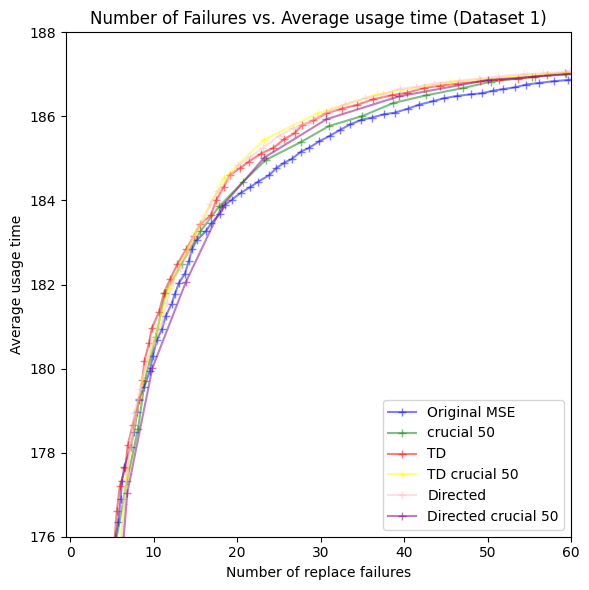

In [78]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(176,188) ### for dataset1

ax.set_xlim(-0.5,60)


# Show the plot
plt.tight_layout()
plt.show()

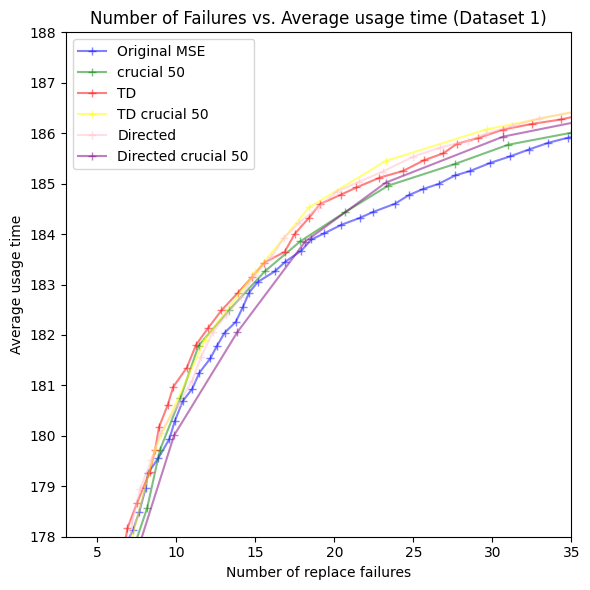

In [79]:
# Create a list of labels
custom_labels = ['Original MSE', 'crucial 50', 'TD', 'TD crucial 50', 'Directed', 'Directed crucial 50']

# Create a list of colors for each dataframe
colors = ['blue', 'green', 'red', 'yellow', 'pink', 'purple']

fig, ax = plt.subplots(figsize=(6, 6))

# Loop through the dataframes and plot scatter points with different colors
for i, result_df in enumerate(result_dfs):
    ax.plot(
        result_df['Number of replace failures'],
        result_df['Average usage time'], '+-',
        label=custom_labels[i],  # Use the custom label from the list
        color=colors[i],
        alpha=0.5
    )

# Set labels and title
ax.set_xlabel('Number of replace failures')
ax.set_ylabel('Average usage time')
ax.set_title('Number of Failures vs. Average usage time (Dataset 1)')

# Add legend
ax.legend()

# Set integer ticks for y-axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylim(178,188) ### for dataset1

ax.set_xlim(3,35)


# Show the plot
plt.tight_layout()
plt.show()

학습된 데이터 프레임을 csv로 저장

In [80]:
# CSV 파일로 저장
for idx, df in enumerate(result_dfs, start=1):
    df.to_csv(f"result_df_{idx}.csv")